# Health Insurance Pricing Case: Clustering and Linear Regression Comparison

## Business Problem

A health insurance company needs better analytical support to define how much to charge for its health plans.

The pricing decision must balance two business goals:

- charge enough to reduce the risk of financial losses;
- remain attractive enough to support customer acquisition.

This project investigates whether different analytical approaches can help explain customer risk and support more informed premium-setting decisions.


## Project Objective

This project compares two approaches for solving the same health insurance pricing case:

1. a clustering-based approach, rebuilt from the completed health insurance case;
2. a linear regression approach, using multiple regression and model refinement through stepwise AIC evaluation.

The goal is to evaluate how each method performs on unseen data and how useful each one is for pricing decisions.


## Analytical Strategy

To ensure a fair comparison, both approaches will be evaluated under the same logic:

1. split the historical dataset into 80% training data and 20% test data;
2. rebuild the clustering workflow using the training set;
3. evaluate clustering on the holdout set and on 3 new incoming clients;
4. rebuild the case with linear regression using the same train-test split logic;
5. compare the predictive behavior, interpretability, and business usefulness of both approaches.


## Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import joblib


In [2]:
# =========================================
# Notebook configuration
# =========================================

RANDOM_STATE = 1

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

## Data Loading

In [3]:
# =========================================
# Reading csv file
# =========================================
base_health_insurance_df = pd.read_csv("../data/base_health_insurance.csv",sep = ";")
display(base_health_insurance_df.head()) 

,age,gender,bmi,children,discount_eligibility,region,expenses,premium
0,19,female,"24,1",0,yes,south,"1483,21","1744,95"
1,18,male,"23,5",1,no,southeast,"2237,61","2632,48"
2,28,male,33,3,no,southeast,"2046,09","2728,12"
3,33,male,"23,3",0,no,midwest,"2331,69","2743,17"
4,32,male,"23,4",0,no,midwest,"1942,5","2285,3"


## Data Validation

In [4]:
# =========================================
# checking data types and missing values
# =========================================

print(base_health_insurance_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   age                   1338 non-null   int64
 1   gender                1338 non-null   str  
 2   bmi                   1338 non-null   str  
 3   children              1338 non-null   int64
 4   discount_eligibility  1338 non-null   str  
 5   region                1338 non-null   str  
 6   expenses              1338 non-null   str  
 7   premium               1338 non-null   str  
dtypes: int64(2), str(6)
memory usage: 83.8 KB
None


## Data Adjustment

Before proceeding with analysis, certain variables require type correction to ensure they are in the appropriate format for computation.

During data validation, it was identified that `bmi`, `expenses`, and `premium` were loaded as strings. Comma separators are replaced and the columns are converted to their correct numeric types. The `discount_eligibility` column is also encoded as a binary variable to enable its use in clustering.

In [5]:
# =========================================
# Data Adjustment
# =========================================

base_health_insurance_df["bmi"] = base_health_insurance_df["bmi"].str.replace(",", ".").astype(float) # replacing comma separator and converting bmi to float

base_health_insurance_df["expenses"] = base_health_insurance_df["expenses"].str.replace(",", ".").astype(float) # replacing comma separator and converting expenses to float

base_health_insurance_df["premium"] = base_health_insurance_df["premium"].str.replace(",", ".").astype(float) # replacing comma separator and converting premium to float

base_health_insurance_df["discount_eligibility_binary"] = np.where(
    base_health_insurance_df["discount_eligibility"] == "yes", 1, 0) # encoding discount eligibility as binary: 1 = yes, 0 = no

display(base_health_insurance_df["discount_eligibility"].unique()) # verifying unique values of original column

print(base_health_insurance_df.info()) # confirming updated data types


<StringArray>
['yes', 'no']
Length: 2, dtype: str

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          1338 non-null   int64  
 1   gender                       1338 non-null   str    
 2   bmi                          1338 non-null   float64
 3   children                     1338 non-null   int64  
 4   discount_eligibility         1338 non-null   str    
 5   region                       1338 non-null   str    
 6   expenses                     1338 non-null   float64
 7   premium                      1338 non-null   float64
 8   discount_eligibility_binary  1338 non-null   int64  
dtypes: float64(3), int64(3), str(3)
memory usage: 94.2 KB
None


## Train-Test Split (80/20)

To evaluate model performance on unseen data, the dataset is split into two subsets:

- **Training set (80%)**: used to fit the models and learn patterns from historical data.
- **Test set (20%)**: kept separate and used only for out-of-sample evaluation.

This separation helps reduce optimistic bias and provides a more realistic estimate of how the approach may perform in real pricing decisions.


In [6]:
from sklearn.model_selection import train_test_split  # function to split data into train and test sets

# splitting the full dataset: 80% for training and 20% for testing
base_health_insurance_train_df, base_health_insurance_test_df = train_test_split(
    base_health_insurance_df,  # source dataframe to split
    train_size=0.80,  # proportion for training set
    random_state=RANDOM_STATE,  # ensures reproducible split
    shuffle=True  # randomly shuffles rows before splitting
)

# resetting index in the training dataframe to keep a clean sequential index
base_health_insurance_train_df = base_health_insurance_train_df.reset_index(drop=True)  # drop old index

# resetting index in the test dataframe to keep a clean sequential index
base_health_insurance_test_df = base_health_insurance_test_df.reset_index(drop=True)  # drop old index

print("Train shape:", base_health_insurance_train_df.shape)  # shows training rows and columns
print("Test shape:", base_health_insurance_test_df.shape)  # shows test rows and columns



Train shape: (1070, 9)
Test shape: (268, 9)


## Clustering Modeling

In this section, the clustering approach is implemented to solve the health insurance pricing case.

The objective is to identify groups of clients with similar risk and cost behavior, so the company can support pricing decisions with a segmented view of the portfolio.

The workflow in this section will include:

- selecting the variables used for clustering;
- standardizing the selected variables to make them comparable;
- defining the number of clusters;
- fitting the clustering model on the training set;
- interpreting cluster profiles in business terms.


## Feature Selection

For the clustering process, the following variables were selected:

- Age  
- BMI  
- Number of children  
- Discount eligibility (to be encoded as binary: 0 = no, 1 = yes)

These variables were chosen because they represent key demographic and behavioral factors that directly influence health risk and, consequently, medical costs.

Age and BMI are strong indicators of health condition and risk exposure.  
The number of children may impact healthcare usage and financial pressure on insurance plans.  
Discount eligibility reflects policy-related segmentation that may influence pricing and customer grouping.

Together, these variables provide a meaningful representation of customer profiles, enabling the identification of distinct clusters for pricing strategy optimization.


In [7]:
# =========================================
# Selecting columns for clustering (training set only)
# =========================================

cluster_columns = ["age", "bmi", "children", "discount_eligibility_binary"]  # variables used in clustering
cluster_train_df = base_health_insurance_train_df[cluster_columns].copy()  # selecting only train rows and clustering columns

display(cluster_train_df.head())  # preview of clustering input (train set)


,age,bmi,children,discount_eligibility_binary
0,53,26.6,0,0
1,53,21.4,1,0
2,18,20.4,0,0
3,60,24.0,0,0
4,45,33.7,1,0


## Data Standardization

Before clustering, all variables must be on the same scale.  
Without standardization, variables with larger ranges (like age) would dominate the distance calculations used by K-Means, producing biased clusters.

StandardScaler transforms each variable to have mean = 0 and standard deviation = 1.

In [8]:
# =========================================
# Data standardization (training set only)
# =========================================

scaler = StandardScaler()  # creating the scaler object
cluster_train_scaled = scaler.fit_transform(cluster_train_df)  # fitting scaler on train data and transforming train data
cluster_train_scaled_df = pd.DataFrame(  # converting scaled array back to dataframe
    cluster_train_scaled,  # scaled numeric values from training set
    columns=cluster_train_df.columns  # preserving original column names
)

display(cluster_train_scaled_df.head())  # preview of standardized training data


,age,bmi,children,discount_eligibility_binary
0,1.002286,-0.251537,-0.907058,-0.508747
1,1.002286,-1.066747,-0.078942,-0.508747
2,-1.504266,-1.223518,-0.907058,-0.508747
3,1.503597,-0.659142,-0.907058,-0.508747
4,0.429360,0.861538,-0.078942,-0.508747


## Elbow Method

To apply K-Means, we need to decide how many clusters (K) best represent the data.
The Elbow Method helps by running K-Means for a range of K values and measuring the inertia —
the sum of squared distances between each point and its assigned centroid.

As K increases, inertia always decreases. The optimal K is the point where the reduction
starts to flatten, forming an "elbow" in the curve. Beyond that point, adding more clusters
brings diminishing returns.


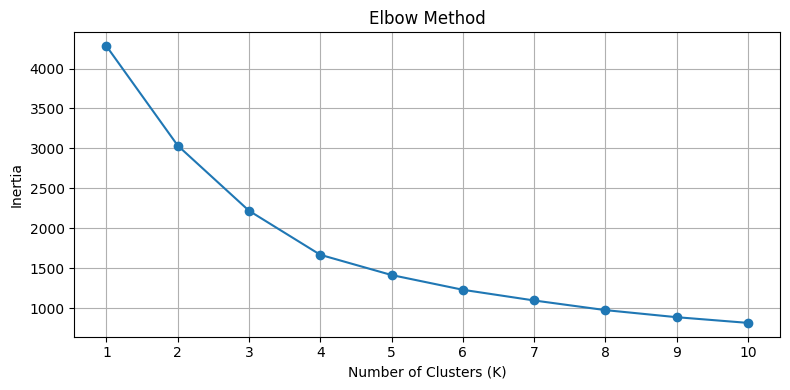

In [9]:
# =========================================
# Elbow Method (training set only)
# =========================================

inertia = []  # list to store inertia values for each tested K
n_clusters = range(1, 11)  # testing K values from 1 to 10

for n in n_clusters:  # looping through each candidate number of clusters
    kmeans_model = KMeans(  # creating a KMeans model for the current K
        n_clusters=n,  # current number of clusters being tested
        random_state=RANDOM_STATE,  # ensuring reproducible centroid initialization
        n_init=10  # running KMeans with 10 different initializations
    )
    kmeans_model.fit(cluster_train_scaled_df)  # fitting model on standardized training data
    inertia.append(kmeans_model.inertia_)  # saving within-cluster sum of squares (inertia)

plt.figure(figsize=(8, 4))  # creating figure with defined size
plt.plot(n_clusters, inertia, marker='o')  # plotting inertia against K
plt.title('Elbow Method')  # setting chart title
plt.xlabel('Number of Clusters (K)')  # labeling x-axis
plt.ylabel('Inertia')  # labeling y-axis
plt.xticks(list(n_clusters))  # forcing x-axis ticks to show each tested K
plt.grid(True)  # adding grid to improve readability
plt.tight_layout()  # adjusting spacing to avoid overlap
plt.show()  # rendering the chart


## Choosing the Number of Clusters

After applying the Elbow Method, the inertia curve was plotted for K values ranging from 2 to 10.

The curve shows a clear inflection point at K=4, where the rate of inertia reduction slows significantly. Beyond this point, adding more clusters brings diminishing returns in compactness.

Therefore, K=4 was selected as the optimal number of clusters for this analysis.


## K-Means Clustering

With the optimal number of clusters defined as K=4, the K-Means algorithm is applied to the standardized dataset.

K-Means works by iteratively assigning each observation to the nearest centroid and recalculating centroids until convergence. The result is a set of cluster labels, one for each customer in the dataset.

The parameter `n_init=50` defines how many times the algorithm is run with different random centroid initializations. Because K-Means is sensitive to the starting positions of centroids, running it multiple times and keeping the best result reduces the risk of converging to a local minimum. A higher value of `n_init` increases the chance of finding a globally optimal solution at the cost of additional computation time.

These labels will be used in the next step to profile each cluster and extract business insights.


In [10]:
# =========================================
# K-Means Clustering - training the K-Means model (training set only)
# =========================================

kmeans_model = KMeans(
    n_clusters=4,  # using the selected number of clusters from elbow analysis
    random_state=RANDOM_STATE,  # ensuring reproducible clustering results
    n_init=50  # running K-Means with multiple initializations for stable convergence
)
kmeans_model.fit(cluster_train_scaled_df)  # fitting K-Means on standardized training data only


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",50
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",1
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


## Cluster Assignment

Each customer in the **training set (80% of the dataset)** will be assigned to one of the four clusters identified by the K-Means algorithm.

The cluster label is stored in a new column called `cluster` in the training dataframe, allowing profile analysis with the original variables (such as age, bmi, expenses, and premium) while preserving the test set (20%) for out-of-sample evaluation.


In [11]:
# =========================================
# Assigning cluster labels to training dataframe (80% split)
# =========================================

base_health_insurance_train_df["cluster"] = kmeans_model.labels_  # assigning cluster IDs only to the training set

display(base_health_insurance_train_df.head())  # preview of training data with cluster column



,age,gender,bmi,children,discount_eligibility,region,expenses,premium,discount_eligibility_binary,cluster
0,53,female,26.6,0,no,midwest,4621.91,4401.82,0,0
1,53,male,21.4,1,no,south,4485.59,4271.99,0,0
2,18,male,20.4,0,no,southeast,1807.87,2126.91,0,1
3,60,female,24.0,0,no,midwest,3897.73,3712.13,0,0
4,45,male,33.7,1,no,south,3696.68,3520.65,0,0


## Saving the Model

With the clustering model trained, it is saved to disk using the joblib library. This allows the model to be reloaded in the future without retraining, enabling the classification of new customers into one of the four identified clusters.

Saving the model is an essential step in making the analysis operational, turning a one-time experiment into a reusable asset for the business.

In [12]:
# =========================================
# Saving the trained K-Means model
# =========================================

kmeans_model_path = "../data/kmeans_model_trained.pkl"  # defining the output path for the trained model
joblib.dump(kmeans_model, kmeans_model_path)  # saving the trained K-Means model to disk

print(f"Model saved at: {kmeans_model_path}")  # confirming where the file was saved


Model saved at: ../data/kmeans_model_trained.pkl


## Cluster Profile Comparison with Overall Training Average

This block applies **descriptive statistics** to compare the profile of each cluster with the overall profile of the full training dataset.

The analysis includes **mean**, **standard deviation**, and **coefficient of variation (CV%)**. Together, these measures help summarize the central tendency and the dispersion of each variable within each cluster and in the full training base.

This comparison is useful for **cluster interpretation**. Instead of only knowing that the algorithm created groups, we can explain what makes each group different in practical terms. For example, we can identify whether a cluster has higher average age, lower average BMI, fewer children, lower average expenses, or different discount eligibility behavior compared with the full training dataset.

This makes the output more useful for business analysis, because it transforms the cluster tables into an interview-friendly summary of how each customer segment differs from the overall portfolio.



In [13]:
# =========================================
# Cluster summary tables: mean, standard deviation, and coefficient of variation
# =========================================

from IPython.display import HTML, display  # importing HTML display tools for notebook output

# defining the variables to summarize and their display labels
summary_columns = {
    "age": "age",
    "bmi": "bmi",
    "children": "children",
    "discount_eligibility_binary": "discount_elig.",
    "expenses": "expenses",
    "premium": "premium"
}

# defining colors used in the CV% font gradient
DARK_BLUE = "#0b3d91"     # very low CV%
LIGHT_BLUE = "#4da3ff"    # transition from blue
LIGHT_GREEN = "#6bd66b"   # transition to green
STRONG_GREEN = "#00a651"  # ideal CV%
YELLOW = "#ffd54f"        # warning zone
ORANGE = "#ff9800"        # transition to high dispersion
STRONG_RED = "#d32f2f"    # very high CV%

# interpolating two hex colors based on a factor between 0 and 1
def interpolate_color(start_hex, end_hex, factor):
    factor = max(0, min(1, factor))  # forcing factor to stay in the valid range

    start_rgb = tuple(int(start_hex[i:i+2], 16) for i in (1, 3, 5))  # converting start color to RGB
    end_rgb = tuple(int(end_hex[i:i+2], 16) for i in (1, 3, 5))      # converting end color to RGB

    mixed_rgb = tuple(
        round(start_rgb[i] + (end_rgb[i] - start_rgb[i]) * factor)   # interpolating each RGB channel
        for i in range(3)
    )

    return "#{:02x}{:02x}{:02x}".format(*mixed_rgb)  # converting RGB back to hex

# applying the CV% gradient color rules to the font color only
def get_cv_font_style(cv_value):
    if pd.isna(cv_value):
        return "color: black; font-weight: bold;"  # neutral style for missing values

    cv_value = max(0, float(cv_value))  # forcing negative values to behave like 0 in the color scale

    # 0% to 5% -> strong blue
    if cv_value <= 5:
        font_color = DARK_BLUE

    # 5.1% to 15% -> transition from blue to green
    elif cv_value <= 15:
        factor = (cv_value - 5) / 10
        font_color = interpolate_color(LIGHT_BLUE, LIGHT_GREEN, factor)

    # 15.1% to 20% -> transition to strong green
    elif cv_value <= 20:
        factor = (cv_value - 15) / 5
        font_color = interpolate_color(LIGHT_GREEN, STRONG_GREEN, factor)

    # 20.1% to 35% -> transition from green to yellow
    elif cv_value <= 35:
        factor = (cv_value - 20) / 15
        font_color = interpolate_color(STRONG_GREEN, YELLOW, factor)

    # 35.1% to 50% -> transition from yellow to red
    elif cv_value <= 50:
        factor = (cv_value - 35) / 15
        font_color = interpolate_color(YELLOW, STRONG_RED, factor)

    # 50.1% to 100% or more -> strong red
    else:
        font_color = STRONG_RED

    return f"color: {font_color}; font-weight: bold;"

# defining a reusable function to build the HTML table
def build_summary_table(dataframe, columns_map, metric_name):
    selected_columns = list(columns_map.keys())  # storing the variables used in the summary

    # calculating the statistic for each cluster and for the full dataframe
    if metric_name == "mean":
        cluster_summary_df = (
            dataframe
            .groupby("cluster", as_index=False)[selected_columns]
            .mean()
            .round(2)
        )
        full_df_summary = dataframe[selected_columns].mean().round(2)
        cluster_prefix = "Av."
        df_prefix = "Av. df"

    elif metric_name == "std":
        cluster_summary_df = (
            dataframe
            .groupby("cluster", as_index=False)[selected_columns]
            .std()
            .round(2)
        )
        full_df_summary = dataframe[selected_columns].std().round(2)
        cluster_prefix = "SD"
        df_prefix = "SD df"

    elif metric_name == "cv":
        # calculating cluster means for the coefficient of variation formula
        cluster_mean_df = dataframe.groupby("cluster", as_index=False)[selected_columns].mean()

        # calculating cluster standard deviations for the coefficient of variation formula
        cluster_std_df = dataframe.groupby("cluster", as_index=False)[selected_columns].std()

        # starting the cluster CV dataframe with the cluster labels
        cluster_summary_df = cluster_mean_df[["cluster"]].copy()

        # calculating the coefficient of variation for each cluster: (std / mean) * 100
        for column_name in selected_columns:
            cluster_summary_df[column_name] = np.where(
                cluster_mean_df[column_name] != 0,
                (cluster_std_df[column_name] / cluster_mean_df[column_name]) * 100,
                np.nan
            )

        # calculating the full-dataframe coefficient of variation
        full_df_mean = dataframe[selected_columns].mean()
        full_df_std = dataframe[selected_columns].std()
        full_df_summary = pd.Series(
            np.where(full_df_mean != 0, (full_df_std / full_df_mean) * 100, np.nan),
            index=selected_columns
        )

        # rounding values for cleaner display
        cluster_summary_df[selected_columns] = cluster_summary_df[selected_columns].round(2)
        full_df_summary = full_df_summary.round(2)

        cluster_prefix = "CV%"
        df_prefix = "CV% df"

    # creating the HTML header dynamically
    header_cells = ["<th>Cluster</th>"]
    for label in columns_map.values():
        header_cells.append(f"<th>{cluster_prefix} {label}</th>")
        header_cells.append(f"<th>{df_prefix} {label}</th>")

    html_table = f"""
    <table border="1" style="border-collapse: collapse; text-align: center; width: 100%; margin-bottom: 14px;">
        <thead>
            <tr>
                {''.join(header_cells)}
            </tr>
        </thead>
        <tbody>
    """

    # defining the number of rows for merged full-dataframe statistic cells
    n_rows = len(cluster_summary_df)

    # building the table body
    for row_index, (_, row) in enumerate(cluster_summary_df.iterrows()):
        html_table += "<tr>"
        html_table += f"<td>{int(row['cluster'])}</td>"

        for column_name in selected_columns:
            cluster_value = row[column_name]  # cluster statistic for the current variable
            df_value = full_df_summary[column_name]  # full-dataframe statistic for the same variable

            # applying color rules for the mean table
            if metric_name == "mean":
                if column_name == "discount_eligibility_binary":
                    if cluster_value == 1.00:
                        cell_style = "color: green; font-weight: bold;"
                    elif cluster_value == 0.00:
                        cell_style = "color: red; font-weight: bold;"
                    else:
                        cell_style = "color: black; font-weight: bold;"
                else:
                    if cluster_value < df_value:
                        cell_style = "color: green; font-weight: bold;"
                    elif cluster_value > df_value:
                        cell_style = "color: red; font-weight: bold;"
                    else:
                        cell_style = "color: black; font-weight: bold;"

                df_cell_style = "vertical-align: middle;"

            # applying color rules for the standard deviation table
            elif metric_name == "std":
                if pd.isna(cluster_value) or pd.isna(df_value):
                    cell_style = "color: black; font-weight: bold;"
                elif cluster_value < df_value:
                    cell_style = "color: green; font-weight: bold;"
                elif cluster_value > df_value:
                    cell_style = "color: red; font-weight: bold;"
                else:
                    cell_style = "color: black; font-weight: bold;"

                df_cell_style = "vertical-align: middle;"

            # applying font-color gradient rules for the CV% table
            elif metric_name == "cv":
                cell_style = get_cv_font_style(cluster_value)  # colored font for cluster CV%
                df_cell_style = "vertical-align: middle; " + get_cv_font_style(df_value)  # colored font for dataframe CV%

            # formatting values, keeping NA when division by zero happens in CV
            cluster_display_value = "NA" if pd.isna(cluster_value) else f"{cluster_value:.2f}"
            df_display_value = "NA" if pd.isna(df_value) else f"{df_value:.2f}"

            # displaying the cluster statistic with its style
            html_table += f"<td style='{cell_style}'>{cluster_display_value}</td>"

            # displaying the merged full-dataframe statistic only once
            if row_index == 0:
                html_table += f"<td rowspan='{n_rows}' style='{df_cell_style}'>{df_display_value}</td>"

        html_table += "</tr>"

    html_table += """
        </tbody>
    </table>
    """

    return html_table

# building the mean table
mean_table_html = build_summary_table(
    dataframe=base_health_insurance_train_df,
    columns_map=summary_columns,
    metric_name="mean"
)

# building the standard deviation table
std_table_html = build_summary_table(
    dataframe=base_health_insurance_train_df,
    columns_map=summary_columns,
    metric_name="std"
)

# building the coefficient of variation table
cv_table_html = build_summary_table(
    dataframe=base_health_insurance_train_df,
    columns_map=summary_columns,
    metric_name="cv"
)

# displaying the three tables one below the other
display(HTML(mean_table_html + std_table_html + cv_table_html))


## Fuzzy-Based Cluster Naming and Interpretation

This block applies a **fuzzy logic interpretation framework** to transform the statistical summaries of each cluster into descriptive names and short explanatory texts.

The goal is not only to identify numerical differences, but also to decide whether those differences are strong, representative, and meaningful enough to describe the cluster. To do this, the logic combines **mean**, **standard deviation**, and **coefficient of variation (CV%)** to evaluate both the level and the consistency of each characteristic.

This approach is useful for **cluster interpretation**, because it turns statistical output into a business-friendly explanation. Instead of seeing clusters only as numbered groups, we can describe them as customer profiles with recognizable traits, such as younger clients, lower BMI, larger families, higher expenses, or unique discount eligibility behavior.

The final output helps make the analysis more interpretable, scalable, and interview-friendly, especially when comparing multiple clusters or applying the same logic to a different dataset.


In [14]:
# =========================================
# Business-friendly cluster naming and interpretation
# with compact notebook layout
# =========================================

from IPython.display import HTML, display
import numpy as np
import pandas as pd
import skfuzzy as fuzz

# checking whether the required dataframe and cluster column exist
if "base_health_insurance_train_df" not in globals():
    raise NameError("The dataframe 'base_health_insurance_train_df' was not found in the notebook environment.")

if "cluster" not in base_health_insurance_train_df.columns:
    raise KeyError("The column 'cluster' was not found. Run the clustering assignment block first.")

# defining the variables used in the interpretation
numeric_columns = ["age", "bmi", "children", "expenses", "premium"]
binary_columns = ["discount_eligibility_binary"]
all_summary_columns = numeric_columns + binary_columns

# keeping only the columns needed for the interpretation
cluster_input_df = base_health_insurance_train_df[["cluster"] + all_summary_columns].copy()

# validating required columns
missing_columns = [column_name for column_name in all_summary_columns if column_name not in cluster_input_df.columns]
if missing_columns:
    raise KeyError(f"These required columns are missing from the dataframe: {missing_columns}")

# calculating summary statistics
cluster_mean_df = cluster_input_df.groupby("cluster")[all_summary_columns].mean()
cluster_std_df = cluster_input_df.groupby("cluster")[all_summary_columns].std(ddof=1)
cluster_size_df = cluster_input_df.groupby("cluster").size().rename("n")
overall_mean = cluster_input_df[all_summary_columns].mean()

# calculating coefficient of variation safely
cluster_cv_df = cluster_std_df.copy()
for column_name in all_summary_columns:
    cluster_cv_df[column_name] = np.where(
        cluster_mean_df[column_name].abs() > 1e-9,
        (cluster_std_df[column_name] / cluster_mean_df[column_name].abs()) * 100,
        np.nan
    )

# defining labels for display
variable_labels = {
    "age": "Age",
    "bmi": "BMI",
    "children": "Children",
    "expenses": "Expenses",
    "premium": "Premium"
}

# title helper mappings (post-processing arrangement)
level_title_map = {
    "age": {
        "much_lower": "younger age",
        "lower": "younger age",
        "close": "Age vary.",
        "higher": "older age",
        "much_higher": "older age"
    },
    "bmi": {
        "much_lower": "low BMI",
        "lower": "lower BMI",
        "close": "BMI vary.",
        "higher": "higher BMI",
        "much_higher": "high BMI"
    },
    "children": {
        "much_lower": "few children",
        "lower": "fewer children",
        "close": "Children vary.",
        "higher": "more children",
        "much_higher": "larger families"
    },
    "expenses": {
        "much_lower": "low expenses",
        "lower": "lower expenses",
        "close": "Expenses vary.",
        "higher": "higher expenses",
        "much_higher": "high expenses"
    },
    "premium": {
        "much_lower": "low premium",
        "lower": "lower premium",
        "close": "Premium vary.",
        "higher": "higher premium",
        "much_higher": "high premium"
    }
}

vary_phrase_map = {
    "age": "Age vary.",
    "bmi": "BMI vary.",
    "children": "Children vary.",
    "expenses": "Expenses vary.",
    "premium": "Premium vary."
}

# formatting numeric values safely
def format_value(value, decimals=2):
    if pd.isna(value):
        return "NA"
    return f"{value:.{decimals}f}"

# escaping html-sensitive characters
def escape_html(text):
    return (
        str(text)
        .replace("&", "&amp;")
        .replace("<", "&lt;")
        .replace(">", "&gt;")
    )

# clipping values to the valid universe interval
def clip_to_universe(value, universe):
    if pd.isna(value):
        return np.nan
    return float(np.clip(value, universe.min(), universe.max()))

# evaluating fuzzy memberships for one crisp value
def get_memberships(value, universe, membership_map):
    if pd.isna(value):
        return {label: 0.0 for label in membership_map}

    clipped_value = clip_to_universe(value, universe)
    return {
        label: float(fuzz.interp_membership(universe, membership_function, clipped_value))
        for label, membership_function in membership_map.items()
    }

# selecting the linguistic label with fuzzy membership and tie-priority
def pick_fuzzy_label(membership_scores, priority_map):
    return max(
        membership_scores.keys(),
        key=lambda label: (membership_scores[label], priority_map.get(label, 0.0))
    )

# generic Mamdani aggregation with centroid defuzzification
def mamdani_centroid(output_universe, output_membership_map, rules):
    aggregated_output = np.zeros_like(output_universe, dtype=float)

    for firing_strength, output_label in rules:
        if firing_strength <= 0:
            continue
        clipped_output = np.fmin(firing_strength, output_membership_map[output_label])
        aggregated_output = np.fmax(aggregated_output, clipped_output)

    if np.max(aggregated_output) <= 1e-9:
        return 0.0, aggregated_output

    crisp_output = float(fuzz.defuzz(output_universe, aggregated_output, "centroid"))
    return crisp_output, aggregated_output

# computing a weighted fuzzy score from label memberships
def weighted_membership_score(membership_scores, label_weights):
    denominator = sum(membership_scores.values())
    if denominator <= 1e-9:
        return 0.0
    numerator = sum(membership_scores[label] * label_weights[label] for label in membership_scores)
    return numerator / denominator

# calculating the relative difference against the full portfolio
def get_relative_difference_pct(cluster_value, overall_value):
    if pd.isna(cluster_value) or pd.isna(overall_value) or abs(overall_value) < 1e-9:
        return 0.0
    return ((cluster_value - overall_value) / abs(overall_value)) * 100

# calculating how far a cluster is from its closest peer for one variable
def get_uniqueness_gap_pct(cluster_id, variable_name):
    cluster_value = cluster_mean_df.loc[cluster_id, variable_name]
    overall_value = overall_mean[variable_name]
    other_cluster_values = cluster_mean_df.drop(index=cluster_id)[variable_name]

    if len(other_cluster_values) == 0 or abs(overall_value) < 1e-9:
        return 0.0

    return (abs(cluster_value - other_cluster_values).min() / abs(overall_value)) * 100

# fuzzy universes
relative_diff_universe = np.linspace(-120, 120, 2401)
cv_universe = np.linspace(0, 150, 1501)
diff_magnitude_universe = np.linspace(0, 120, 1201)
uniqueness_universe = np.linspace(0, 100, 1001)
importance_universe = np.linspace(0, 100, 1001)
discount_pct_universe = np.linspace(0, 100, 1001)
contrast_universe = np.linspace(0, 100, 1001)

# fuzzy sets for level versus portfolio mean
a = relative_diff_universe
level_membership_map = {
    "much_lower": fuzz.trapmf(a, [-120, -120, -40, -18]),
    "lower": fuzz.trapmf(a, [-28, -16, -10, -5]),
    "close": fuzz.trapmf(a, [-12, -8, 8, 12]),
    "higher": fuzz.trapmf(a, [5, 10, 16, 28]),
    "much_higher": fuzz.trapmf(a, [18, 40, 120, 120])
}

# fuzzy sets for spread based on CV%
b = cv_universe
spread_membership_map = {
    "very_low": fuzz.trapmf(b, [0, 0, 6, 12]),
    "low": fuzz.trapmf(b, [8, 14, 22, 30]),
    "moderate": fuzz.trapmf(b, [24, 32, 40, 50]),
    "high": fuzz.trapmf(b, [45, 55, 70, 85]),
    "very_high": fuzz.trapmf(b, [80, 95, 150, 150])
}

# fuzzy sets for distance magnitude from average
c = diff_magnitude_universe
diff_magnitude_membership_map = {
    "low": fuzz.trapmf(c, [0, 0, 4, 10]),
    "medium": fuzz.trapmf(c, [8, 15, 25, 35]),
    "high": fuzz.trapmf(c, [30, 45, 120, 120])
}

# fuzzy sets for uniqueness against peer clusters
d = uniqueness_universe
uniqueness_membership_map = {
    "low": fuzz.trapmf(d, [0, 0, 6, 16]),
    "medium": fuzz.trapmf(d, [12, 20, 35, 50]),
    "high": fuzz.trapmf(d, [40, 55, 100, 100])
}

# fuzzy sets for consistency (inverse of spread)
consistency_membership_map = {
    "stable": fuzz.trapmf(b, [0, 0, 18, 32]),
    "mixed": fuzz.trapmf(b, [24, 34, 46, 60]),
    "unstable": fuzz.trapmf(b, [52, 72, 150, 150])
}

# fuzzy output sets for feature importance
e = importance_universe
importance_membership_map = {
    "weak": fuzz.trapmf(e, [0, 0, 22, 40]),
    "moderate": fuzz.trapmf(e, [30, 45, 60, 75]),
    "strong": fuzz.trapmf(e, [65, 78, 88, 95]),
    "very_strong": fuzz.trapmf(e, [90, 96, 100, 100])
}

# fuzzy sets for discount intensity
f = discount_pct_universe
discount_membership_map = {
    "almost_no": fuzz.trapmf(f, [0, 0, 4, 12]),
    "relevant_share": fuzz.trapmf(f, [8, 20, 80, 92]),
    "almost_all": fuzz.trapmf(f, [88, 94, 99.5, 99.9]),
    "all": fuzz.trapmf(f, [99.8, 99.95, 100, 100])
}

# fuzzy sets for contrast between one cluster and the others
g = contrast_universe
contrast_membership_map = {
    "low": fuzz.trapmf(g, [0, 0, 6, 16]),
    "moderate": fuzz.trapmf(g, [12, 22, 36, 50]),
    "high": fuzz.trapmf(g, [42, 58, 100, 100])
}

# tie-priority maps to keep language stable in overlap zones
level_priority = {"close": 5, "lower": 4, "higher": 4, "much_lower": 3, "much_higher": 3}
spread_priority = {"moderate": 5, "low": 4, "high": 4, "very_low": 3, "very_high": 3}
discount_priority = {"all": 5, "almost_all": 4, "relevant_share": 3, "almost_no": 2}

# cache to avoid recomputing fuzzy outputs
feature_cache = {}

# building short naming phrases for each variable
def get_name_phrase(variable_name, level):
    name_mapping = {
        "age": {
            "much_lower": "young",
            "lower": "younger",
            "close": "mid-age",
            "higher": "older",
            "much_higher": "older"
        },
        "bmi": {
            "much_lower": "low BMI",
            "lower": "lower BMI",
            "close": "moderate BMI",
            "higher": "higher BMI",
            "much_higher": "high BMI"
        },
        "children": {
            "much_lower": "few children",
            "lower": "fewer children",
            "close": "typical family size",
            "higher": "more children",
            "much_higher": "larger families"
        },
        "expenses": {
            "much_lower": "low expenses",
            "lower": "lower expenses",
            "close": "mid expenses",
            "higher": "higher expenses",
            "much_higher": "high expenses"
        },
        "premium": {
            "much_lower": "low premium",
            "lower": "lower premium",
            "close": "mid premium",
            "higher": "higher premium",
            "much_higher": "high premium"
        }
    }
    return name_mapping[variable_name][level]

# writing the first sentence for each numeric variable
def get_main_description(variable_name, level):
    if variable_name == "age":
        mapping = {
            "much_lower": "This is a clearly younger group, well below the portfolio average.",
            "lower": "This group is younger than the portfolio average.",
            "close": "Age is very close to the overall portfolio average.",
            "higher": "This group is older than the portfolio average.",
            "much_higher": "This is a clearly older group, well above the portfolio average."
        }
        return mapping[level]

    if variable_name == "bmi":
        mapping = {
            "much_lower": "Clients have a clearly lower-than-average BMI, indicating a healthier profile.",
            "lower": "Clients have a lower-than-average BMI, indicating a healthier profile.",
            "close": "BMI is close to the portfolio average.",
            "higher": "Clients have a higher-than-average BMI, indicating a less healthy profile.",
            "much_higher": "Clients have a much higher-than-average BMI, indicating a less healthy profile."
        }
        return mapping[level]

    if variable_name == "children":
        mapping = {
            "much_lower": "Most clients have few or no children.",
            "lower": "Most clients have relatively few children.",
            "close": "Family size is similar to the overall portfolio.",
            "higher": "Clients tend to have more children than average.",
            "much_higher": "This cluster stands out for having larger families."
        }
        return mapping[level]

    if variable_name == "expenses":
        mapping = {
            "much_lower": "Medical costs are much lower than average.",
            "lower": "Medical costs are below average.",
            "close": "Medical costs are close to the portfolio average.",
            "higher": "Medical costs are above average.",
            "much_higher": "Medical costs are significantly higher than average."
        }
        return mapping[level]

    if variable_name == "premium":
        mapping = {
            "much_lower": "Insurance premiums are also much lower.",
            "lower": "Insurance premiums are also lower.",
            "close": "Premiums are close to the portfolio average.",
            "higher": "Insurance premiums are also higher.",
            "much_higher": "Insurance premiums are also much higher."
        }
        return mapping[level]

    return "This variable is close to the portfolio average."

# writing the second sentence based on the amount of variation
def get_spread_description(variable_name, spread_level, level):
    if variable_name == "age":
        mapping = {
            "very_low": "Clients are very close in age, meaning most of them are consistently in the same life stage.",
            "low": "Most clients are concentrated in a similar life stage, with limited variation in age.",
            "moderate": "There is some variation, meaning the group includes both slightly younger and older clients.",
            "high": "There is high variation, meaning the group includes both younger and older clients.",
            "very_high": "Age varies a lot in this cluster, so it brings together clients from quite different life stages.",
            "unclear": "Age pattern is not clear enough to summarize with confidence."
        }
        return mapping[spread_level]

    if variable_name == "bmi":
        mapping = {
            "very_low": "BMI is very consistent, with most clients staying close to the same range.",
            "low": "BMI does not vary much within the group, meaning most clients are fairly similar on this point.",
            "moderate": "There is some variation, but the group still follows a fairly clear BMI pattern.",
            "high": "BMI varies noticeably, so not all clients fit the same profile.",
            "very_high": "BMI varies a lot across the group, so clients are spread across different body profiles.",
            "unclear": "BMI pattern is not clear enough to summarize with confidence."
        }
        return mapping[spread_level]

    if variable_name == "children":
        if level in ["much_lower", "lower"]:
            mapping = {
                "very_low": "Almost everyone in the group has a similarly small family structure.",
                "low": "This is quite consistent across the group, with most clients having few children.",
                "moderate": "There is some variation, but smaller families still dominate the cluster.",
                "high": "However, this varies a lot across the group, with some clients having larger families.",
                "very_high": "However, family size varies widely, with some clients having much larger families.",
                "unclear": "Family structure is not clear enough to summarize with confidence."
            }
        elif level in ["much_higher", "higher"]:
            mapping = {
                "very_low": "Most clients look very similar on this point, with family size consistently above average.",
                "low": "While most have more children, the group still follows a fairly consistent family pattern.",
                "moderate": "While most have more children, there is still some variation across clients.",
                "high": "There is noticeable variation, with both medium and larger families inside the cluster.",
                "very_high": "Family size varies a lot, mixing very different household structures.",
                "unclear": "Family structure is not clear enough to summarize with confidence."
            }
        else:
            mapping = {
                "very_low": "Family size is very similar across the group.",
                "low": "Most clients have a similar family structure.",
                "moderate": "There is some variation in family size, but no strong contrast.",
                "high": "However, this varies a lot, with different family structures inside the group.",
                "very_high": "Family size varies widely, combining very different household profiles.",
                "unclear": "Family structure is not clear enough to summarize with confidence."
            }
        return mapping[spread_level]

    if variable_name == "expenses":
        mapping = {
            "very_low": "Spending is very stable, meaning most clients generate very similar costs.",
            "low": "Spending is relatively stable, meaning most clients follow a similar cost pattern.",
            "moderate": "There is some variation in spending, but the overall cost profile is still clear.",
            "high": "However, spending varies across the group, with some clients spending much more than others.",
            "very_high": "Spending varies widely, combining low-cost and high-cost clients in the same cluster.",
            "unclear": "The spending pattern is not clear enough to summarize with confidence."
        }
        return mapping[spread_level]

    if variable_name == "premium":
        mapping = {
            "very_low": "Values are very similar across clients, reinforcing a consistent risk profile.",
            "low": "Values are stable across the group, reflecting a fairly consistent risk profile.",
            "moderate": "There is some variation in premium values, but the general pricing pattern is still clear.",
            "high": "There is noticeable variation, indicating different risk levels within the cluster.",
            "very_high": "Premium values vary widely, showing a mix of lower-risk and higher-risk clients.",
            "unclear": "The premium pattern is not clear enough to summarize with confidence."
        }
        return mapping[spread_level]

    return "This pattern is not clear enough to summarize."

# fuzzy inference for level label
def infer_level_label(relative_difference_pct):
    level_scores = get_memberships(relative_difference_pct, relative_diff_universe, level_membership_map)
    level_label = pick_fuzzy_label(level_scores, level_priority)
    return level_label, level_scores

# fuzzy inference for spread label
def infer_spread_label(cv_value):
    if pd.isna(cv_value):
        return "unclear", {label: 0.0 for label in spread_membership_map}

    spread_scores = get_memberships(cv_value, cv_universe, spread_membership_map)
    spread_label = pick_fuzzy_label(spread_scores, spread_priority)
    return spread_label, spread_scores

# fuzzy inference for feature strength (used for cluster naming)
def infer_feature_strength(cluster_id, variable_name):
    cluster_value = cluster_mean_df.loc[cluster_id, variable_name]
    overall_value = overall_mean[variable_name]

    relative_difference_pct = get_relative_difference_pct(cluster_value, overall_value)
    diff_magnitude_pct = abs(relative_difference_pct)
    uniqueness_gap_pct = get_uniqueness_gap_pct(cluster_id, variable_name)
    cv_value = cluster_cv_df.loc[cluster_id, variable_name]

    level_label, level_scores = infer_level_label(relative_difference_pct)
    spread_label, spread_scores = infer_spread_label(cv_value)

    diff_scores = get_memberships(diff_magnitude_pct, diff_magnitude_universe, diff_magnitude_membership_map)
    uniqueness_scores = get_memberships(uniqueness_gap_pct, uniqueness_universe, uniqueness_membership_map)
    consistency_scores = get_memberships(cv_value, cv_universe, consistency_membership_map)

    if sum(consistency_scores.values()) <= 1e-9:
        consistency_scores = {"stable": 0.34, "mixed": 0.33, "unstable": 0.33}

    rules = [
        (min(diff_scores["high"], uniqueness_scores["high"], consistency_scores["stable"]), "very_strong"),
        (min(diff_scores["high"], uniqueness_scores["medium"], consistency_scores["stable"]), "strong"),
        (min(diff_scores["high"], uniqueness_scores["high"], consistency_scores["mixed"]), "strong"),
        (min(diff_scores["medium"], uniqueness_scores["high"], consistency_scores["stable"]), "strong"),
        (min(diff_scores["medium"], uniqueness_scores["medium"], consistency_scores["stable"]), "moderate"),
        (min(diff_scores["medium"], uniqueness_scores["medium"], consistency_scores["mixed"]), "moderate"),
        (min(diff_scores["high"], consistency_scores["unstable"]), "moderate"),
        (min(diff_scores["medium"], consistency_scores["unstable"]), "weak"),
        (diff_scores["low"], "weak"),
        (min(diff_scores["medium"], uniqueness_scores["low"]), "weak"),
        (min(diff_scores["high"], uniqueness_scores["low"], consistency_scores["stable"]), "moderate")
    ]

    strength_score, _ = mamdani_centroid(importance_universe, importance_membership_map, rules)

    return {
        "relative_difference_pct": relative_difference_pct,
        "level_label": level_label,
        "level_scores": level_scores,
        "spread_label": spread_label,
        "spread_scores": spread_scores,
        "strength_score": strength_score
    }

# cached access to fuzzy feature output
def get_feature_output(cluster_id, variable_name):
    cache_key = (int(cluster_id), variable_name)
    if cache_key not in feature_cache:
        feature_cache[cache_key] = infer_feature_strength(cluster_id, variable_name)
    return feature_cache[cache_key]

# fuzzy inference for the discount first sentence
def infer_discount_label(cluster_pct):
    discount_scores = get_memberships(cluster_pct, discount_pct_universe, discount_membership_map)
    discount_label = pick_fuzzy_label(discount_scores, discount_priority)
    return discount_label, discount_scores

# fuzzy inference for how much discount behavior sets one cluster apart
def infer_discount_distinction(cluster_pct, max_other_pct, min_other_pct):
    discount_label, discount_scores = infer_discount_label(cluster_pct)

    stronger_gap = max(cluster_pct - max_other_pct, 0.0)
    weaker_gap = max(min_other_pct - cluster_pct, 0.0)

    stronger_scores = get_memberships(stronger_gap, contrast_universe, contrast_membership_map)
    weaker_scores = get_memberships(weaker_gap, contrast_universe, contrast_membership_map)

    rules = [
        (min(max(discount_scores["all"], discount_scores["almost_all"]), stronger_scores["high"]), "very_strong"),
        (min(max(discount_scores["all"], discount_scores["almost_all"]), stronger_scores["moderate"]), "strong"),
        (min(discount_scores["relevant_share"], stronger_scores["high"]), "strong"),
        (min(discount_scores["almost_no"], weaker_scores["high"]), "strong"),
        (min(discount_scores["almost_no"], weaker_scores["moderate"]), "moderate"),
        (min(discount_scores["relevant_share"], weaker_scores["high"]), "moderate"),
        (min(discount_scores["relevant_share"], stronger_scores["moderate"]), "moderate"),
        (max(stronger_scores["low"], weaker_scores["low"]), "weak")
    ]

    distinction_score, _ = mamdani_centroid(importance_universe, importance_membership_map, rules)

    stronger_direction_score = weighted_membership_score(stronger_scores, {"low": 20, "moderate": 60, "high": 100})
    weaker_direction_score = weighted_membership_score(weaker_scores, {"low": 20, "moderate": 60, "high": 100})

    return {
        "discount_label": discount_label,
        "discount_scores": discount_scores,
        "distinction_score": distinction_score,
        "stronger_direction_score": stronger_direction_score,
        "weaker_direction_score": weaker_direction_score
    }

# building the numeric explanation
def build_numeric_explanation(cluster_id, variable_name):
    feature_output = get_feature_output(cluster_id, variable_name)

    first_sentence = get_main_description(variable_name, feature_output["level_label"])
    second_sentence = get_spread_description(
        variable_name,
        feature_output["spread_label"],
        feature_output["level_label"]
    )

    return {
        "label": variable_labels[variable_name],
        "line_1": first_sentence,
        "line_2": second_sentence
    }

# building the discount explanation
def build_discount_explanation(cluster_id):
    cluster_pct = cluster_mean_df.loc[cluster_id, "discount_eligibility_binary"] * 100
    other_rates = cluster_mean_df.drop(index=cluster_id)["discount_eligibility_binary"] * 100

    discount_label, discount_scores = infer_discount_label(cluster_pct)

    first_sentence_map = {
        "almost_no": "Almost no clients receive discounts.",
        "relevant_share": "A relevant share of clients receive discounts.",
        "almost_all": "Almost all clients receive discounts.",
        "all": "All clients receive discounts."
    }
    first_sentence = first_sentence_map[discount_label]

    if len(other_rates) > 0:
        max_other = float(other_rates.max())
        min_other = float(other_rates.min())

        # explicit exclusivity rule keeps discount as main business driver when unique
        if cluster_pct >= 99.5 and max_other <= 1.0:
            second_sentence = "This is the main defining feature of the cluster and clearly sets it apart."
        else:
            distinction_output = infer_discount_distinction(cluster_pct, max_other, min_other)
            distinction_score = distinction_output["distinction_score"]
            stronger_direction_score = distinction_output["stronger_direction_score"]
            weaker_direction_score = distinction_output["weaker_direction_score"]

            if (
                distinction_score >= 70
                and discount_scores["almost_no"] >= 0.60
                and weaker_direction_score > stronger_direction_score
            ):
                second_sentence = "This is one point that helps separate the group from the others."
            elif distinction_score >= 65 and stronger_direction_score > weaker_direction_score:
                second_sentence = "This stands out strongly compared with the other clusters."
            elif distinction_score >= 65 and weaker_direction_score > stronger_direction_score:
                second_sentence = "This is noticeably weaker here than in the other clusters."
            else:
                second_sentence = "This helps describe the group, but it is not the only defining characteristic."
    else:
        second_sentence = "There are no other clusters available for comparison."

    return {
        "label": "Discount eligibility",
        "line_1": first_sentence,
        "line_2": second_sentence
    }

# building the core cluster name from fuzzy evidence
def build_cluster_name_core(cluster_id):
    name_parts = []
    represented_variables = set()

    cluster_pct = cluster_mean_df.loc[cluster_id, "discount_eligibility_binary"] * 100
    other_rates = cluster_mean_df.drop(index=cluster_id)["discount_eligibility_binary"] * 100

    if len(other_rates) > 0:
        max_other = float(other_rates.max())
        min_other = float(other_rates.min())

        # explicit exclusivity rule keeps title fidelity when discount is unique to one cluster
        if cluster_pct >= 99.5 and max_other <= 1.0:
            name_parts.append("Discount-Eligible Clients")
            represented_variables.add("discount_eligibility_binary")
        else:
            discount_context = infer_discount_distinction(cluster_pct, max_other, min_other)
            if (
                discount_context["discount_label"] in ["all", "almost_all"]
                and discount_context["distinction_score"] >= 75
                and discount_context["stronger_direction_score"] >= discount_context["weaker_direction_score"]
            ):
                name_parts.append("Discount-Eligible Clients")
                represented_variables.add("discount_eligibility_binary")
            elif (
                discount_context["discount_label"] == "almost_no"
                and discount_context["distinction_score"] >= 70
                and discount_context["weaker_direction_score"] > discount_context["stronger_direction_score"]
            ):
                name_parts.append("No-Discount Clients")
                represented_variables.add("discount_eligibility_binary")

    feature_candidates = []
    for variable_name in numeric_columns:
        feature_output = get_feature_output(cluster_id, variable_name)
        level = feature_output["level_label"]
        phrase = get_name_phrase(variable_name, level)

        # only candidate when variable actually contributes as a trait
        if level == "close":
            continue

        if feature_output["spread_scores"].get("high", 0.0) + feature_output["spread_scores"].get("very_high", 0.0) >= 0.60:
            phrase = phrase + "*"

        feature_candidates.append({
            "variable": variable_name,
            "phrase": phrase,
            "score": feature_output["strength_score"],
            "level": level
        })

    feature_candidates = sorted(feature_candidates, key=lambda item: item["score"], reverse=True)

    for candidate in feature_candidates:
        if len(name_parts) >= 3:
            break
        if candidate["score"] < 52 and len(name_parts) >= 1:
            continue
        if candidate["phrase"] not in name_parts:
            name_parts.append(candidate["phrase"])
            represented_variables.add(candidate["variable"])

    if not name_parts:
        name_parts = ["balanced profile"]

    return ", ".join(name_parts), represented_variables

# post-processing arrangement requested:
# keep main trait first, then add remaining variables in parentheses.
# if a variable has no relevant trait, mark as "vary."
def arrange_cluster_title(cluster_id, base_title, represented_variables):
    arrangement_threshold = 60
    tail_parts = []

    for variable_name in numeric_columns:
        if variable_name in represented_variables:
            continue

        feature_output = get_feature_output(cluster_id, variable_name)
        level = feature_output["level_label"]

        if level != "close" and feature_output["strength_score"] >= arrangement_threshold:
            tail_phrase = level_title_map[variable_name][level]
        else:
            tail_phrase = vary_phrase_map[variable_name]

        if tail_phrase not in tail_parts:
            tail_parts.append(tail_phrase)

    if not tail_parts:
        return base_title

    return f"{base_title} ({', '.join(tail_parts)})"

# building the HTML block for one cluster
def build_cluster_html(cluster_id):
    base_cluster_name, represented_variables = build_cluster_name_core(cluster_id)
    cluster_name = arrange_cluster_title(cluster_id, base_cluster_name, represented_variables)
    cluster_n = int(cluster_size_df.loc[cluster_id])

    html_parts = []
    html_parts.append("<div style='margin-bottom: 22px;'>")
    html_parts.append(
        f"<div style='font-size: 22px; font-weight: 700; margin-bottom: 6px;'>"
        f"Cluster {cluster_id}: <span style='font-weight: 800;'>{escape_html(cluster_name)}</span>"
        f"</div>"
    )
    html_parts.append(
        f"<div style='font-size: 16px; margin-bottom: 10px;'>"
        f"Cluster size: {cluster_n} clients"
        f"</div>"
    )

    for variable_name in numeric_columns:
        explanation = build_numeric_explanation(cluster_id, variable_name)

        html_parts.append(
            f"<div style='font-size: 16px; line-height: 1.32; margin-bottom: 2px;'>"
            f"<span style='font-weight: 700; text-decoration: underline;'>"
            f"{escape_html(explanation['label'])}:"
            f"</span> "
            f"{escape_html(explanation['line_1'])}"
            f"</div>"
        )
        html_parts.append(
            f"<div style='font-size: 16px; line-height: 1.32; margin-bottom: 8px;'>"
            f"{escape_html(explanation['line_2'])}"
            f"</div>"
        )

    discount_explanation = build_discount_explanation(cluster_id)
    html_parts.append(
        f"<div style='font-size: 16px; line-height: 1.32; margin-bottom: 2px;'>"
        f"<span style='font-weight: 700; text-decoration: underline;'>"
        f"{escape_html(discount_explanation['label'])}:"
        f"</span> "
        f"{escape_html(discount_explanation['line_1'])}"
        f"</div>"
    )
    html_parts.append(
        f"<div style='font-size: 16px; line-height: 1.32; margin-bottom: 8px;'>"
        f"{escape_html(discount_explanation['line_2'])}"
        f"</div>"
    )

    if "*" in cluster_name:
        html_parts.append(
            "<div style='font-size: 14px; font-style: italic; margin-top: 4px;'>"
            "*The asterisk means this trait helps define the cluster, but not all clients follow it closely.*"
            "</div>"
        )

    html_parts.append("</div>")
    return "".join(html_parts)

# generating the final formatted report
all_cluster_html = []
for cluster_id in sorted(cluster_mean_df.index.tolist()):
    all_cluster_html.append(build_cluster_html(cluster_id))

final_html = (
    "<div style='font-family: Arial, sans-serif; color: #f2f2f2; padding: 2px 1px;'>"
    + "".join(all_cluster_html)
    + "</div>"
)

# displaying the result in the notebook
display(HTML(final_html))


## CHECK POINT: Business Validation of Clustering

At this stage, technical metrics alone are not enough. The final validation of clustering depends on business knowledge.

We must confirm three strategic questions:
1. Do these clusters make business sense?
2. Do they allow differentiated decisions?
3. Do they reveal distinct risk and cost profiles that justify different pricing?

Our practical goal is to assign each new client to a cluster and estimate how much we can charge. This assignment may contain individual errors (for example, a not-so-young client being placed in Cluster 0). Even so, the approach can still be useful if it performs well on average.

The central risk question is: **how risky is it to assume this client will have cost \(x\), based on the cluster mean?**

To evaluate this risk, we use cluster variability (standard deviation):
- Low standard deviation: costs are more concentrated, so pricing can stay closer to the cluster mean.
- High standard deviation: costs are more dispersed, uncertainty is higher, and a more conservative (higher) price is recommended.

Therefore, if a client is assigned to a high-variability cluster, increasing the price is a reasonable risk-protection strategy.


In [15]:
#==========================================================================================================
# Renaming columns of statistic sub-dataframes to friendly labels
#==========================================================================================================

# checking whether the required dataframes exist in memory
required_dataframes = ["cluster_mean_df", "cluster_std_df", "cluster_cv_df"]  # dataframe names we need
missing_dataframes = [df_name for df_name in required_dataframes if df_name not in globals()]  # finding missing ones
if missing_dataframes:
    raise NameError(f"Missing dataframe(s): {missing_dataframes}")  # stopping execution if any dataframe is missing

# creating a label map to keep friendly names in the final headers
base_label_map = {
    "age": "age",  # keeping the same readable label for age
    "bmi": "bmi",  # keeping the same readable label for bmi
    "children": "children",  # keeping the same readable label for children
    "discount_eligibility_binary": "discount_elig.",  # shortening discount column label
    "expenses": "expenses",  # keeping the same readable label for expenses
    "premium": "premium"  # keeping the same readable label for premium
}

# creating a reusable function to rename every non-cluster column with a prefix
def rename_columns_with_prefix(dataframe, prefix):
    renamed_df = dataframe.copy()  # copying dataframe to avoid accidental side effects while renaming
    renamed_df = renamed_df.rename(columns=base_label_map)  # applying friendly base labels first

    # adding the requested prefix to all variable columns
    renamed_df = renamed_df.rename(
        columns=lambda column_name: column_name if str(column_name).lower() == "cluster" else f"{prefix} {column_name}"
    )

    return renamed_df  # returning the renamed dataframe

# applying the renaming rules requested for each dataframe
cluster_mean_df = rename_columns_with_prefix(cluster_mean_df, "Av.")  # example: age -> Av. age
cluster_std_df = rename_columns_with_prefix(cluster_std_df, "SD")  # example: age -> SD age
cluster_cv_df = rename_columns_with_prefix(cluster_cv_df, "CV%")  # example: age -> CV% age

# previewing the first rows of each renamed dataframe
display(cluster_mean_df.head())  # showing renamed cluster means
display(cluster_std_df.head())  # showing renamed cluster standard deviations
display(cluster_cv_df.head())  # showing renamed cluster CV%


,Av. age,Av. bmi,Av. children,Av. expenses,Av. premium,Av. discount_elig.
cluster,,,,,,
0,52.855124,31.928975,0.416961,4713.261767,4502.666219,0.0
1,26.363363,22.841742,0.549550,1893.973724,2228.204264,0.0
2,40.700855,31.562393,2.735043,2097.744530,2796.992821,0.0
3,38.518182,27.959091,1.050000,2618.748409,2862.107136,1.0


,SD age,SD bmi,SD children,SD expenses,SD premium,SD discount_elig.
cluster,,,,,,
0,7.265253,5.884799,0.554794,743.861097,671.897077,0.0
1,7.126024,1.842577,0.699467,327.329888,385.094021,0.0
2,10.518543,5.686876,0.848054,674.041967,898.722896,0.0
3,13.991669,6.394094,1.139675,1393.711152,1167.963300,0.0


,CV% age,CV% bmi,CV% children,CV% expenses,CV% premium,CV% discount_elig.
cluster,,,,,,
0,13.745598,18.430905,133.056532,15.782300,14.922205,NaN
1,27.030027,8.066709,127.280091,17.282705,17.282707,NaN
2,25.843543,18.017885,31.006982,32.131747,32.131756,NaN
3,36.324842,22.869463,108.540449,53.220506,40.807812,0.0


## Cluster Analysis Business DataFrame

This block applies descriptive statistics to organize the main cluster indicators into a single table for business interpretation.

The objective is to support a business-oriented analysis of the clusters by making profile comparison clearer and helping pricing decisions become more consistent.
```** }}


In [16]:
# creating cluster_analysis_df from cluster_mean_df
cluster_analysis_business_df = cluster_mean_df.copy()  # using cluster_mean_df as the base dataframe

# adding existing columns from the project summary dataframes
cluster_analysis_business_df["SD expenses"] = cluster_std_df["SD expenses"].values  # adding SD expenses
cluster_analysis_business_df["CV% expenses"] = cluster_cv_df["CV% expenses"].values  # adding CV% expenses
# reorganizing columns in the requested order
cluster_analysis_business_df = cluster_analysis_business_df[
    [
        "Av. age",
        "Av. bmi",
        "Av. children",
        "Av. discount_elig.",
        "Av. expenses",
        "SD expenses",
        "Av. premium",
        "CV% expenses",
    ]
]  # keeping only requested columns and order

# displaying final dataframe
display(cluster_analysis_business_df)  # showing the final result


,Av. age,Av. bmi,Av. children,Av. discount_elig.,Av. expenses,SD expenses,Av. premium,CV% expenses
cluster,,,,,,,,
0,52.855124,31.928975,0.416961,0.0,4713.261767,743.861097,4502.666219,15.782300
1,26.363363,22.841742,0.549550,0.0,1893.973724,327.329888,2228.204264,17.282705
2,40.700855,31.562393,2.735043,0.0,2097.744530,674.041967,2796.992821,32.131747
3,38.518182,27.959091,1.050000,1.0,2618.748409,1393.711152,2862.107136,53.220506


## Cluster Business Profitability Metrics

This block applies a business profitability view to each cluster by calculating two financial indicators from the existing averages.

`Av. Profit (R$)` is calculated as:

$$
\mathrm{Av.\ Profit\ (R\$)} = \mathrm{Av.\ premium} - \mathrm{Av.\ expenses}
$$

This metric shows the average monetary gain per customer in each cluster.

`Profit Margin (%)` is calculated as:

$$
\mathrm{Profit\ Margin\ (\%)} = \left( \frac{\mathrm{Av.\ Profit\ (R\$)}}{\mathrm{Av.\ premium}} \right) \times 100
$$

This metric shows the percentage of premium revenue that remains as profit after average expenses, helping compare cluster profitability in a business-oriented way.


In [17]:
# adding business columns based on the formulas from the image:
# Average Profit = Av. premium - Av. expenses
# Profit Margin = Average Profit / Av. premium

cluster_analysis_business_df["Av. Profit (R$)"] = (
    cluster_analysis_business_df["Av. premium"] - cluster_analysis_business_df["Av. expenses"]
).round(2)  # calculating average profit per cluster

cluster_analysis_business_df["Profit Margin (%)"] = (
    (cluster_analysis_business_df["Av. Profit (R$)"] / cluster_analysis_business_df["Av. premium"]) * 100
).round(2)  # calculating profit margin in percentage


display(cluster_analysis_business_df)  # displaying final dataframe


,Av. age,Av. bmi,Av. children,Av. discount_elig.,Av. expenses,SD expenses,Av. premium,CV% expenses,Av. Profit (R$),Profit Margin (%)
cluster,,,,,,,,,,
0,52.855124,31.928975,0.416961,0.0,4713.261767,743.861097,4502.666219,15.782300,-210.60,-4.68
1,26.363363,22.841742,0.549550,0.0,1893.973724,327.329888,2228.204264,17.282705,334.23,15.00
2,40.700855,31.562393,2.735043,0.0,2097.744530,674.041967,2796.992821,32.131747,699.25,25.00
3,38.518182,27.959091,1.050000,1.0,2618.748409,1393.711152,2862.107136,53.220506,243.36,8.50


## Desired Profit Margin by Cluster
 `Desired Profit Margin (%)` is a variable which defines the target margin for each cluster.

The primary estimation rule is risk-based: as `CV% expenses` increases, the desired margin should also increase to absorb higher cost uncertainty and reduce pricing risk.

However, there is a deliberate exception in this case: **Cluster 3** (our model) has the highest variability (`53.22%`) but receives the lowest desired margin (`20%`).

This is a strategic business decision. Cluster 3 is the discount-eligible segment, so the lower target margin is used to keep pricing attractive, increase customer acquisition, and strengthen retention in a price-sensitive group.

Even with this lower target margin, the segment remains financially viable in the case results (positive average profit and positive margin). In practice, this means accepting lower unit margin in exchange for commercial scale and long-term recurring revenue, while keeping performance under monitoring.

| Cluster | Desired Profit Margin |
|---|---|
| 0 | 25% |
| 1 | 25% |
| 2 | 20% |
| 3 | 30% |

In [18]:
# adding desired margin targets by PROJECT cluster id
# external table L-column (0:25, 1:25, 2:20, 3:30) mapped to project ids:
# project 0 <- external 1, project 1 <- external 0, project 2 <- external 3, project 3 <- external 2
desired_profit_margin_pct_map = {0: 25, 1: 25, 2: 30, 3: 20}  # desired margin in percentage points

# inserting Desired Profit Margin (%)
cluster_analysis_business_df["Desired Profit Margin (%)"] = cluster_analysis_business_df.index.map(
    desired_profit_margin_pct_map
)  # mapping target margin per cluster

# converting desired margin to decimal for formulas
desired_margin_decimal = cluster_analysis_business_df["Desired Profit Margin (%)"] / 100  # % -> decimal

# column M (Valor a Ser Cobrado): Av. expenses / (1 - desired margin)
cluster_analysis_business_df["Amount to Charge (R$)"] = (
    cluster_analysis_business_df["Av. expenses"] / (1 - desired_margin_decimal)
).round(2)  # expected premium to charge under desired margin

# column N (Lucro Medio Esperado): Amount to Charge - Av. expenses
cluster_analysis_business_df["Expected Average Profit (R$)"] = (
    cluster_analysis_business_df["Amount to Charge (R$)"] - cluster_analysis_business_df["Av. expenses"]
).round(2)  # expected average profit per cluster

# column O (Custo Medio Esperado): Amount to Charge - Expected Average Profit
cluster_analysis_business_df["Expected Average Cost (R$)"] = (
    cluster_analysis_business_df["Amount to Charge (R$)"] - cluster_analysis_business_df["Expected Average Profit (R$)"]
).round(2)  # expected average cost (should match Av. expenses)

# displaying updated dataframe
display(cluster_analysis_business_df)  # showing dataframe with new L, M, N, O logic


,Av. age,Av. bmi,Av. children,Av. discount_elig.,Av. expenses,SD expenses,Av. premium,CV% expenses,Av. Profit (R$),Profit Margin (%),Desired Profit Margin (%),Amount to Charge (R$),Expected Average Profit (R$),Expected Average Cost (R$)
cluster,,,,,,,,,,,,,,
0,52.855124,31.928975,0.416961,0.0,4713.261767,743.861097,4502.666219,15.782300,-210.60,-4.68,25,6284.35,1571.09,4713.26
1,26.363363,22.841742,0.549550,0.0,1893.973724,327.329888,2228.204264,17.282705,334.23,15.00,25,2525.30,631.33,1893.97
2,40.700855,31.562393,2.735043,0.0,2097.744530,674.041967,2796.992821,32.131747,699.25,25.00,30,2996.78,899.04,2097.74
3,38.518182,27.959091,1.050000,1.0,2618.748409,1393.711152,2862.107136,53.220506,243.36,8.50,20,3273.44,654.69,2618.75


In [19]:
#=========================================
# Cretae a df with fuzzy cluster titles and merge with financial info for final output
#=========================================

# creating compatibility aliases expected by the fuzzy title functions
cluster_mean_df["age"] = cluster_mean_df["Av. age"]  # alias for fuzzy logic
cluster_mean_df["bmi"] = cluster_mean_df["Av. bmi"]  # alias for fuzzy logic
cluster_mean_df["children"] = cluster_mean_df["Av. children"]  # alias for fuzzy logic
cluster_mean_df["expenses"] = cluster_mean_df["Av. expenses"]  # alias for fuzzy logic
cluster_mean_df["premium"] = cluster_mean_df["Av. premium"]  # alias for fuzzy logic
cluster_mean_df["discount_eligibility_binary"] = cluster_mean_df["Av. discount_elig."]  # alias for fuzzy logic

cluster_cv_df["age"] = cluster_cv_df["CV% age"]  # alias for fuzzy logic
cluster_cv_df["bmi"] = cluster_cv_df["CV% bmi"]  # alias for fuzzy logic
cluster_cv_df["children"] = cluster_cv_df["CV% children"]  # alias for fuzzy logic
cluster_cv_df["expenses"] = cluster_cv_df["CV% expenses"]  # alias for fuzzy logic
cluster_cv_df["premium"] = cluster_cv_df["CV% premium"]  # alias for fuzzy logic
cluster_cv_df["discount_eligibility_binary"] = cluster_cv_df["CV% discount_elig."]  # alias for fuzzy logic

# clearing fuzzy cache so titles are recalculated with current values
feature_cache = {}  # resetting cache

# creating dataframe with fuzzy cluster titles
cluster_title_df = pd.DataFrame({"cluster": cluster_analysis_business_df.index})  # cluster ids
cluster_title_df["Cluster Title"] = cluster_title_df["cluster"].apply(
    lambda cluster_id: arrange_cluster_title(cluster_id, *build_cluster_name_core(cluster_id))
)  # generating fuzzy title per cluster

# selecting business columns required in the final output
cluster_finance_df = cluster_analysis_business_df.reset_index()[
    [
        "cluster",
        "Av. premium",
        "Av. Profit (R$)",
        "Profit Margin (%)",
        "Desired Profit Margin (%)",
        "Amount to Charge (R$)",
        "Expected Average Profit (R$)",
        "Expected Average Cost (R$)",
    ]
].rename(
    columns={"Av. premium": "Av. Premium (R$)"}
)  # financial columns with display naming aligned to the formatting cell

# merging title + pricing info
cluster_pricing_summary_df = cluster_title_df.merge(
    cluster_finance_df,
    on="cluster",
    how="left"
)  # final merge

# displaying final dataframe
display(cluster_pricing_summary_df)  # output: cluster / title / desired margin / amount to charge


,cluster,Cluster Title,Av. Premium (R$),Av. Profit (R$),Profit Margin (%),Desired Profit Margin (%),Amount to Charge (R$),Expected Average Profit (R$),Expected Average Cost (R$)
0,0,"high expenses, high premium, older (BMI vary., Children vary.)",4502.666219,-210.60,-4.68,25,6284.35,1571.09,4713.26
1,1,"young, lower BMI, few children* (Expenses vary., Premium vary.)",2228.204264,334.23,15.00,25,2525.30,631.33,1893.97
2,2,"larger families (Age vary., BMI vary., Expenses vary., Premium vary.)",2796.992821,699.25,25.00,30,2996.78,899.04,2097.74
3,3,"Discount-Eligible Clients (Age vary., BMI vary., Children vary., Expenses vary., Premium vary.)",2862.107136,243.36,8.50,20,3273.44,654.69,2618.75


In [20]:
# formatting helper without unit symbols in cell values
def format_br_number(value, decimals=2):
    if pd.isna(value):  # keeping empty text for missing values
        return ""
    return f"{value:,.{decimals}f}".replace(",", "X").replace(".", ",").replace("X", ".")  # BR number format

# creating a display copy to avoid changing the original dataframe
cluster_pricing_summary_display_df = cluster_pricing_summary_df.copy()  # safe display-only copy

# ensuring desired margin column has (%) in the header
if "Desired Profit Margin (%)" not in cluster_pricing_summary_display_df.columns and "Desired Profit Margin" in cluster_pricing_summary_display_df.columns:
    cluster_pricing_summary_display_df = cluster_pricing_summary_display_df.rename(
        columns={"Desired Profit Margin": "Desired Profit Margin (%)"}
    )  # standardizing the column title

# adding Av. Expenses from cluster_analysis_business_df using cluster id as key
cluster_pricing_summary_display_df["Av. Expenses (R$)"] = cluster_pricing_summary_display_df["cluster"].map(
    cluster_analysis_business_df["Av. expenses"]
)  # bringing average expenses into the display dataframe

# formatting numeric columns without showing unit symbols in values
cluster_pricing_summary_display_df["Av. Expenses (R$)"] = cluster_pricing_summary_display_df["Av. Expenses (R$)"].map(
    lambda x: format_br_number(x, 2)
)  # keeping only numeric text
cluster_pricing_summary_display_df["Av. Profit (R$)"] = cluster_pricing_summary_display_df["Av. Profit (R$)"].map(
    lambda x: format_br_number(x, 2)
)  # keeping only numeric text
cluster_pricing_summary_display_df["Expected Average Profit (R$)"] = cluster_pricing_summary_display_df["Expected Average Profit (R$)"].map(
    lambda x: format_br_number(x, 2)
)  # keeping only numeric text
cluster_pricing_summary_display_df["Expected Average Cost (R$)"] = cluster_pricing_summary_display_df["Expected Average Cost (R$)"].map(
    lambda x: format_br_number(x, 2)
)  # keeping only numeric text
cluster_pricing_summary_display_df["Profit Margin (%)"] = cluster_pricing_summary_display_df["Profit Margin (%)"].map(
    lambda x: format_br_number(x, 2)
)  # keeping only numeric text
cluster_pricing_summary_display_df["Desired Profit Margin (%)"] = cluster_pricing_summary_display_df["Desired Profit Margin (%)"].map(
    lambda x: format_br_number(x, 0)
)  # keeping only numeric text

# coloring Av. Premium values in red (without "R$" in values)
cluster_pricing_summary_display_df["Av. Premium (R$)"] = cluster_pricing_summary_df["Av. Premium (R$)"].map(
    lambda x: f"<span style='color:#d32f2f; font-weight:700'>{format_br_number(x, 2)}</span>"
)  # red highlight

# coloring Amount to Charge values in green (without "R$" in values)
cluster_pricing_summary_display_df["Amount to Charge (R$)"] = cluster_pricing_summary_df["Amount to Charge (R$)"].map(
    lambda x: f"<span style='color:#00a651; font-weight:700'>{format_br_number(x, 2)}</span>"
)  # green highlight

# placing Av. Expenses between Cluster Title and Av. Premium
ordered_columns = [
    col for col in cluster_pricing_summary_display_df.columns
    if col not in ["Av. Expenses (R$)", "Av. Premium (R$)"]
]  # temporarily removing both columns from the order
insert_position = ordered_columns.index("Cluster Title") + 1  # position right after Cluster Title
ordered_columns[insert_position:insert_position] = ["Av. Expenses (R$)", "Av. Premium (R$)"]  # inserting in requested order
cluster_pricing_summary_display_df = cluster_pricing_summary_display_df[ordered_columns]  # applying final column order

# rendering HTML table (works without pandas .style / jinja2)
display(HTML(cluster_pricing_summary_display_df.to_html(index=False, escape=False)))  # final display


cluster,Cluster Title,Av. Expenses (R$),Av. Premium (R$),Av. Profit (R$),Profit Margin (%),Desired Profit Margin (%),Amount to Charge (R$),Expected Average Profit (R$),Expected Average Cost (R$)
0,"high expenses, high premium, older (BMI vary., Children vary.)","4.713,26","4.502,67","-210,60","-4,68",25,"6.284,35","1.571,09","4.713,26"
1,"young, lower BMI, few children* (Expenses vary., Premium vary.)","1.893,97","2.228,20","334,23","15,00",25,"2.525,30","631,33","1.893,97"
2,"larger families (Age vary., BMI vary., Expenses vary., Premium vary.)","2.097,74","2.796,99","699,25","25,00",30,"2.996,78","899,04","2.097,74"
3,"Discount-Eligible Clients (Age vary., BMI vary., Children vary., Expenses vary., Premium vary.)","2.618,75","2.862,11","243,36","8,50",20,"3.273,44","654,69","2.618,75"


## Cluster Pricing and Profitability Summary

This table consolidates the business view of each cluster by combining current performance metrics and target pricing metrics in one place.

It helps compare:
- the current average premium and profitability of each cluster;
- the desired margin strategy adopted for each segment;
- the expected financial outcome after applying the target pricing (`Amount to Charge`).

Column meanings:
- `cluster`: numeric identifier of each customer segment generated by clustering.
- `Cluster Title`: business-friendly fuzzy-logic label that summarizes the profile of the cluster.
- `Av. Premium (R$)`: current average premium charged in the cluster.
- `Av. Profit (R$)`: current average monetary profit (`Av. Premium - Av. expenses`).
- `Profit Margin (%)`: current profit percentage over premium.
- `Desired Profit Margin (%)`: target margin defined by business strategy for that cluster.
- `Amount to Charge (R$)`: target premium required to achieve the desired margin.
- `Expected Average Profit (R$)`: expected profit after applying the target premium.
- `Expected Average Cost (R$)`: expected average cost baseline used in the projection (aligned with average expenses).


## Client-Level Pricing Simulation (Training Set)

This block translates the cluster pricing strategy into a client-level view using the 80% training base (already labeled by cluster).

The objective is to compare, for each client:
- the target premium based on cluster strategy (`Amount to Charge (R$)`),
- the hypothetical profit under this target (`Profit we'd have (R$)`),
- and the current realized profit from the existing premium (`Profit we made (R$)`).

This comparison helps evaluate whether the proposed pricing strategy improves profitability while preserving a clear business interpretation at the individual-customer level.


In [21]:
# creating a client-level dataframe from the 80% training base (already with cluster per client)
client_cluster_pricing_df = base_health_insurance_train_df.copy()  # keeping all original columns

# creating a lookup from cluster to target amount to charge
amount_to_charge_by_cluster = cluster_analysis_business_df["Amount to Charge (R$)"]  # index = cluster

# adding pricing column per client
client_cluster_pricing_df["Amount to Charge (R$)"] = client_cluster_pricing_df["cluster"].map(
    amount_to_charge_by_cluster
)  # assigning target amount by cluster

# adding requested profit columns with (R$) in the title
client_cluster_pricing_df["Profit we'd have (R$)"] = (
    client_cluster_pricing_df["Amount to Charge (R$)"] - client_cluster_pricing_df["expenses"]
).round(2)  # hypothetical profit using target charge

client_cluster_pricing_df["Profit we made (R$)"] = (
    client_cluster_pricing_df["premium"] - client_cluster_pricing_df["expenses"]
).round(2)  # actual profit using current premium

# creating a display copy with wrapped headers for long column names
client_cluster_pricing_display_df = client_cluster_pricing_df.rename(
    columns={
        "expenses": "expenses (R$)",  # wrapping long header
        "premium": "premium (R$)",  # wrapping long header
        "discount_eligibility": "discount_eligibility",  # wrapping long header
        "discount_eligibility_binary": "discount_eligibility",  # wrapping long header
        "Amount to Charge (R$)": "Amount to Charge (R$)",  # wrapping long header
        "Profit we'd have (R$)": "Profit we'd have (R$)",  # wrapping long header
        "Profit we made (R$)": "Profit we made (R$)",  # wrapping long header
    }
)

# displaying result
display(client_cluster_pricing_display_df.head())  # change to display(...) if you want all rows


,age,gender,bmi,children,discount_eligibility,region,expenses (R$),premium (R$),discount_eligibility,cluster,Amount to Charge (R$),Profit we'd have (R$),Profit we made (R$)
0,53,female,26.6,0,no,midwest,4621.91,4401.82,0,0,6284.35,1662.44,-220.09
1,53,male,21.4,1,no,south,4485.59,4271.99,0,0,6284.35,1798.76,-213.60
2,18,male,20.4,0,no,southeast,1807.87,2126.91,0,1,2525.30,717.43,319.04
3,60,female,24.0,0,no,midwest,3897.73,3712.13,0,0,6284.35,2386.62,-185.60
4,45,male,33.7,1,no,south,3696.68,3520.65,0,0,6284.35,2587.67,-176.03


In [22]:
# calculating total premium amounts for each scenario in the 80% client base
total_current_premium = client_cluster_pricing_df["premium"].sum()  # sum of currently charged premiums
total_sugested_premium = client_cluster_pricing_df["Amount to Charge (R$)"].sum()  # sum of suggested premiums

# calculating total profit for each scenario
profit_total_current = round(client_cluster_pricing_df["Profit we made (R$)"].sum(), 2)  # current total profit
profit_total_sugested = round(client_cluster_pricing_df["Profit we'd have (R$)"].sum(), 2)  # simulated total profit

# calculating profit margin (%) for each scenario using total premium as denominator
profit_margin_current = round((profit_total_current / total_current_premium) * 100, 2) if total_current_premium != 0 else np.nan  # current margin
profit_margin_sugested = round((profit_total_sugested / total_sugested_premium) * 100, 2) if total_sugested_premium != 0 else np.nan  # simulated margin

# creating a 2x2 summary table with requested columns and rows
profit_summary_df = pd.DataFrame(
    {
        "Currently Premium": [profit_total_current, profit_margin_current],  # values for current pricing
        "Sugested Premium": [profit_total_sugested, profit_margin_sugested],  # values for suggested pricing
    },
    index=["Profit Total (R$)", "Profit Margin (%)"]  # requested row labels
)

# rendering the final table in HTML format
display(HTML(profit_summary_df.to_html()))


,Currently Premium,Sugested Premium
Profit Total (R$),268863.25,1009256.07
Profit Margin (%),8.15,24.98


## Clustering Technique Conclusion

This case shows that clustering is effective for turning heterogeneous clients into actionable pricing segments. By grouping customers with similar profile and cost behavior, we could define differentiated target margins and compute a cluster-based `Amount to Charge (R$)`.

The final totals dataframe compares current realized profit (`Profit Total we made (R$)`) with simulated profit under the proposed cluster pricing policy (`Profit Total we'd have (R$)`). The simulated total is substantially higher, indicating that the cluster-driven strategy improves expected profitability on the 80% training base.

In business terms, the clustering approach delivered:
- clear segment interpretation for pricing decisions;
- measurable financial upside in the pricing simulation.

This supports clustering as a practical pricing framework, with continuous monitoring when extending the strategy to unseen clients.


## Transition to the 20% Holdout Client Base

Up to this point, the clustering analysis and related calculations were performed using the 80% training client base.

Now we will start working with the 20% holdout client base, which has not yet been included in the calculations.

The first step is to enrich this holdout dataset by assigning cluster labels based on the K-Means structure learned from the 80% training data, using the same preprocessing logic. This allows a fair out-of-sample evaluation on unseen clients.


## Classifying the 20% Holdout Client Base with the Trained Clustering Model

Now we will work with the **20% holdout client base**, which contains unseen clients not used during model training.

In this step, we will classify each holdout client into one of the clusters learned from the **80% training client base**.  
To keep the evaluation statistically valid, we will use the same clustering variables, apply the same scaler fitted on the training set, and then use the trained K-Means model to predict cluster membership.

The result will be a new `cluster` column in `base_health_insurance_test_df`, enabling a fair out-of-sample comparison between the clustering and linear regression approaches.


In [23]:
cluster_columns = ["age", "bmi", "children", "discount_eligibility_binary"]  # same feature set used to train K-Means

cluster_test_df = base_health_insurance_test_df[cluster_columns].copy()  # selecting holdout features to be classified
cluster_test_scaled = scaler.transform(cluster_test_df)  # normalizing holdout data with the scaler fitted on the 80% training set

cluster_test_scaled_df = pd.DataFrame(  # converting scaled array back to DataFrame to keep feature names
    cluster_test_scaled,  # standardized numeric values for holdout clients
    columns=cluster_columns,  # preserving the exact feature names expected by the model
    index=cluster_test_df.index  # preserving row alignment with the original holdout dataframe
)

kmeans_model_loaded = joblib.load("../data/kmeans_model_trained.pkl")  # loading the trained K-Means model from disk
base_health_insurance_test_df["cluster"] = kmeans_model_loaded.predict(cluster_test_scaled_df)  # assigning cluster to each holdout client

display(base_health_insurance_test_df.head())  # previewing the holdout dataframe with the new cluster column


,age,gender,bmi,children,discount_eligibility,region,expenses,premium,discount_eligibility_binary,cluster
0,19,male,22.9,0,no,midwest,1653.18,1944.92,0,1
1,57,male,31.5,0,no,midwest,5589.00,5322.85,0,0
2,51,male,37.0,0,no,south,5159.52,4913.83,0,0
3,49,female,36.6,3,no,southeast,3315.35,4420.46,0,2
4,21,male,23.4,1,no,south,1413.54,1662.99,0,1


## Financial Enrichment of the 20% Holdout Client Base

In this step, we enrich each client in `base_health_insurance_test_df` with financial indicators derived from:

1. the client’s own observed values (`expenses`, `premium`);
2. the financial profile of the cluster assigned by the model trained on the 80% base.

This allows us to evaluate cluster-based pricing on unseen clients at the **individual row level**.

### Added columns and interpretation

- `Profit we made (R$)`  
  Current realized result per client.  
  **Formula:** `premium - expenses`.

- `Av. Cluster Expenses (R$)`  
  Expected average expense for the client’s assigned cluster (reference from 80% training-cluster analysis).

- `Error Cliente Charge (R$)`  
  Absolute deviation between client actual expense and the expected cluster expense.  
  **Formula:** `expenses - Av. Cluster Expenses (R$)`.

- `Error Cliente Charge (%)`  
  Relative deviation (percentage) from the cluster expected expense.  
  **Formula:** `Error Cliente Charge (R$) / Av. Cluster Expenses (R$) * 100`.

- `Amount to Charge (R$)`  
  Suggested premium for the assigned cluster according to the cluster pricing strategy.

- `Profit we'd made (R$)`  
  Simulated result if the client were charged the cluster-suggested premium.  
  **Formula:** `Amount to Charge (R$) - expenses`.

### Why this block is important

This enrichment converts the holdout set into an evaluation-ready dataset, enabling a fair out-of-sample comparison between:

- current pricing performance, and
- cluster-based suggested pricing performance.


In [24]:
# building a numeric cluster-level reference table from the 80% training analysis
cluster_finance_ref_df = cluster_analysis_business_df.copy()  # source with cluster financial metrics

if "cluster" not in cluster_finance_ref_df.columns:  # when cluster id is in the index
    cluster_finance_ref_df = cluster_finance_ref_df.reset_index()  # moving index to column

required_ref_cols = ["cluster", "Av. expenses", "Amount to Charge (R$)"]  # required reference fields
missing_ref_cols = [col for col in required_ref_cols if col not in cluster_finance_ref_df.columns]  # checking missing columns
if missing_ref_cols:
    raise KeyError(f"Missing required columns in cluster_analysis_business_df: {missing_ref_cols}")  # stopping with clear message

cluster_finance_ref_df = cluster_finance_ref_df[required_ref_cols].drop_duplicates(subset=["cluster"])  # one row per cluster

cluster_finance_ref_df["cluster"] = pd.to_numeric(cluster_finance_ref_df["cluster"], errors="coerce")  # ensuring numeric key
cluster_finance_ref_df["Av. expenses"] = pd.to_numeric(cluster_finance_ref_df["Av. expenses"], errors="coerce")  # ensuring numeric values
cluster_finance_ref_df["Amount to Charge (R$)"] = pd.to_numeric(cluster_finance_ref_df["Amount to Charge (R$)"], errors="coerce")  # ensuring numeric values

# creating fast lookup series by cluster id
av_expenses_by_cluster = cluster_finance_ref_df.set_index("cluster")["Av. expenses"]  # average expense by cluster
amount_to_charge_by_cluster = cluster_finance_ref_df.set_index("cluster")["Amount to Charge (R$)"]  # suggested premium by cluster

# ensuring holdout cluster column is numeric for consistent mapping
base_health_insurance_test_df["cluster"] = pd.to_numeric(base_health_insurance_test_df["cluster"], errors="coerce")  # aligning key type

# adding cluster-derived financial references to each holdout client
base_health_insurance_test_df["Av. Cluster Expenses (R$)"] = base_health_insurance_test_df["cluster"].map(av_expenses_by_cluster)  # expected cost from assigned cluster
base_health_insurance_test_df["Amount to Charge (R$)"] = base_health_insurance_test_df["cluster"].map(amount_to_charge_by_cluster)  # suggested premium from assigned cluster

# adding client-level current and simulated results
base_health_insurance_test_df["Profit we made (R$)"] = (
    base_health_insurance_test_df["premium"] - base_health_insurance_test_df["expenses"]  # current charged premium minus actual expense
)

base_health_insurance_test_df["Error estimated expenses (R$)"] = (
    base_health_insurance_test_df["expenses"] - base_health_insurance_test_df["Av. Cluster Expenses (R$)"]  # deviation from cluster expected expense
)

base_health_insurance_test_df["Error estimated expenses (%)"] = np.where(
    base_health_insurance_test_df["Av. Cluster Expenses (R$)"] != 0,  # avoiding division by zero
    (base_health_insurance_test_df["Error estimated expenses (R$)"] / base_health_insurance_test_df["Av. Cluster Expenses (R$)"]) * 100,  # percentage deviation
    np.nan  # undefined when denominator is zero
)

base_health_insurance_test_df["Profit we'd made (R$)"] = (
    base_health_insurance_test_df["Amount to Charge (R$)"] - base_health_insurance_test_df["expenses"]  # suggested premium minus actual expense
)

# rounding final analytical columns for readability
base_health_insurance_test_df[
    [
        "Profit we made (R$)",
        "Av. Cluster Expenses (R$)",
        "Error estimated expenses (R$)",
        "Error estimated expenses (%)",
        "Amount to Charge (R$)",
        "Profit we'd made (R$)",
    ]
] = base_health_insurance_test_df[
    [
        "Profit we made (R$)",
        "Av. Cluster Expenses (R$)",
        "Error estimated expenses (R$)",
        "Error estimated expenses (%)",
        "Amount to Charge (R$)",
        "Profit we'd made (R$)",
    ]
].round(2)

# previewing enriched holdout dataframe
display(HTML(base_health_insurance_test_df.head().to_html(index=False)))


age,gender,bmi,children,discount_eligibility,region,expenses,premium,discount_eligibility_binary,cluster,Av. Cluster Expenses (R$),Amount to Charge (R$),Profit we made (R$),Error estimated expenses (R$),Error estimated expenses (%),Profit we'd made (R$)
19,male,22.9,0,no,midwest,1653.18,1944.92,0,1,1893.97,2525.30,291.74,-240.79,-12.71,872.12
57,male,31.5,0,no,midwest,5589.00,5322.85,0,0,4713.26,6284.35,-266.15,875.74,18.58,695.35
51,male,37.0,0,no,south,5159.52,4913.83,0,0,4713.26,6284.35,-245.69,446.26,9.47,1124.83
49,female,36.6,3,no,southeast,3315.35,4420.46,0,2,2097.74,2996.78,1105.11,1217.61,58.04,-318.57
21,male,23.4,1,no,south,1413.54,1662.99,0,1,1893.97,2525.30,249.45,-480.43,-25.37,1111.76


## Preliminary Client-Level Price Adjustment Impact

At this stage, we measure how the proposed premium adjustment affects each client individually before making any retention assumptions.

- `Customer Payment Difference (R$)` shows the monetary difference between the current premium and the recommended amount to charge.
- `Customer Payment Difference (%)` expresses this same difference as a percentage of the current premium.
- `Premium Increase for Client (%)` reframes the change from the client perspective (positive values mean the client would pay more; negative values mean the client would pay less).

This is a diagnostic step, not a final pricing decision. Increasing the premium may improve expected revenue per client, but it does not automatically mean higher total revenue, because clients may become dissatisfied with a higher plan price.

For now, the objective is only to quantify the impact for each client. The viability of premium increases will be evaluated in the next stage of the analysis.


In [25]:
# validating the minimum required columns in the holdout dataframe
required_holdout_columns = ["premium", "cluster", "children", "age"]  # columns required for pricing and MNL logic
missing_holdout_columns = [col for col in required_holdout_columns if col not in base_health_insurance_test_df.columns]  # checking missing columns
if missing_holdout_columns:
    raise KeyError(f"Missing required columns in base_health_insurance_test_df: {missing_holdout_columns}")  # stopping early with explicit message

# validating that the cluster business table has the target pricing column
if "Amount to Charge (R$)" not in cluster_analysis_business_df.columns:
    raise KeyError("Missing 'Amount to Charge (R$)' in cluster_analysis_business_df.")  # required for payment difference calculations

# coercing numeric fields for safe arithmetic
for col in ["premium", "cluster", "children", "age"]:
    base_health_insurance_test_df[col] = pd.to_numeric(base_health_insurance_test_df[col], errors="coerce")  # forcing numeric type

# adding holdout target premium by cluster when not already present
if "Amount to Charge (R$)" not in base_health_insurance_test_df.columns:
    amount_to_charge_by_cluster = cluster_analysis_business_df["Amount to Charge (R$)"]  # cluster -> target premium lookup
    base_health_insurance_test_df["Amount to Charge (R$)"] = base_health_insurance_test_df["cluster"].map(amount_to_charge_by_cluster)  # mapping cluster pricing

# ensuring mapped target premium is numeric
base_health_insurance_test_df["Amount to Charge (R$)"] = pd.to_numeric(
    base_health_insurance_test_df["Amount to Charge (R$)"], errors="coerce"
)  # coercing mapped values to numeric

# requested column 1: current premium minus cluster target premium
base_health_insurance_test_df["Customer Payment Difference (R$)"] = (
    base_health_insurance_test_df["premium"] - base_health_insurance_test_df["Amount to Charge (R$)"]
)  # positive means customer currently pays above target; negative means below target

# requested column 2: payment difference as % of current premium
base_health_insurance_test_df["Customer Payment Difference (%)"] = np.where(
    base_health_insurance_test_df["premium"] != 0,  # avoiding division by zero
    (base_health_insurance_test_df["Customer Payment Difference (R$)"] / base_health_insurance_test_df["premium"]) * 100,  # percentage difference
    np.nan  # undefined when premium is zero
)

# helper interpretation column for churn model input (positive = customer would pay more)
base_health_insurance_test_df["Premium Increase for Client (%)"] = (
    -base_health_insurance_test_df["Customer Payment Difference (%)"]
)  # inverse sign of payment difference %

# rounding the financial-difference outputs
base_health_insurance_test_df[
    ["Customer Payment Difference (R$)", "Customer Payment Difference (%)", "Premium Increase for Client (%)"]
] = base_health_insurance_test_df[
    ["Customer Payment Difference (R$)", "Customer Payment Difference (%)", "Premium Increase for Client (%)"]
].round(2)

# preview focused on pricing-difference interpretation
display_columns_step1 = [
    "age",
    "children",
    "premium",
    "Amount to Charge (R$)",
    "Customer Payment Difference (R$)",
    "Customer Payment Difference (%)",
    "Premium Increase for Client (%)",
]
display(HTML(base_health_insurance_test_df.head().to_html(index=False)))


age,gender,bmi,children,discount_eligibility,region,expenses,premium,discount_eligibility_binary,cluster,Av. Cluster Expenses (R$),Amount to Charge (R$),Profit we made (R$),Error estimated expenses (R$),Error estimated expenses (%),Profit we'd made (R$),Customer Payment Difference (R$),Customer Payment Difference (%),Premium Increase for Client (%)
19,male,22.9,0,no,midwest,1653.18,1944.92,0,1,1893.97,2525.30,291.74,-240.79,-12.71,872.12,-580.38,-29.84,29.84
57,male,31.5,0,no,midwest,5589.00,5322.85,0,0,4713.26,6284.35,-266.15,875.74,18.58,695.35,-961.50,-18.06,18.06
51,male,37.0,0,no,south,5159.52,4913.83,0,0,4713.26,6284.35,-245.69,446.26,9.47,1124.83,-1370.52,-27.89,27.89
49,female,36.6,3,no,southeast,3315.35,4420.46,0,2,2097.74,2996.78,1105.11,1217.61,58.04,-318.57,1423.68,32.21,-32.21
21,male,23.4,1,no,south,1413.54,1662.99,0,1,1893.97,2525.30,249.45,-480.43,-25.37,1111.76,-862.31,-51.85,51.85


## Evidence Base: Premium Increase and Customer Exit Risk

A bibliographic review was conducted to identify real-world evidence on whether premium increases are associated with customer exit (switching plans or dropping coverage).  
The most relevant and comparable evidence to our context is summarized below.

### Case 1 — Employer Health Plans (AJMC, 2004)
In an employee health insurance setting, premium increases were associated with both switching and coverage drop:
- With a 10% relative premium increase, singles: **7% drop/cut coverage**, **13% switch**, **80% keep**.
- With the same 10% increase, families: **11% drop/cut coverage**, **12% switch**, **77% keep**.
- With ~20% increase, about **20% of singles** dropped coverage (vs **10% of families**).

### Case 2 — Medicaid Premium Threshold (Dague, 2014)
Using a regression discontinuity design in Wisconsin Medicaid/CHIP:
- Moving from no premium to a required premium (starting at $10/month at eligibility thresholds) reduced retention.
- At the adult threshold, the probability of staying enrolled for >12 months fell by about **11.8 p.p.**.
- Enrollment spell duration also fell (around **1.35 months** in the main threshold estimate).

### Case 3 — Oregon Health Plan Redesign (2003 policy change)
After higher premiums/cost-sharing and stricter payment rules:
- Enrollment in the affected population declined by about **46%** (from **88,874** to **47,957** between Feb and Dec 2003).
- Among those who lost coverage, about **44%** reported program costs/missed premium as the main reason.

### Supporting Literature (for economic mechanism and sensitivity)
A broader modern empirical literature also documents strong premium sensitivity:
- Premium exposure can significantly increase disenrollment, especially among healthier, lower-cost individuals, reinforcing the risk of adverse selection under higher prices.

Because our project also evaluates plan repricing, we will use this evidence as justification to model **customer exit probability** instead of assuming that higher premium always converts into higher realized revenue.

### References
1. Goldman DP, Leibowitz AA, Robalino DA. *Employee Responses to Health Insurance Premium Increases*. AJMC (2004).  
   https://www.ajmc.com/view/jan04-1676p41-47

2. Dague L. *The effect of Medicaid premiums on enrollment: A regression discontinuity approach*. Journal of Health Economics 37 (2014) 1–12.  
   https://ccf.georgetown.edu/wp-content/uploads/2012/03/Dague-Premiums.pdf

3. Wright BJ et al. *Short-Term Impacts of Coverage Loss in a Medicaid Population: Early Results From a Prospective Cohort Study of the Oregon Health Plan*.  
   https://pmc.ncbi.nlm.nih.gov/articles/PMC1578659/

4. Cliff BQ et al. NBER Working Paper (premium sensitivity and disenrollment evidence in low-income public coverage).  
   https://www.nber.org/system/files/working_papers/w28762/w28762.pdf


## Reference Case Chosen for Modeling Exit Probability

We chose the **AJMC 2004 employee health insurance case** as the primary methodological reference.

### Why this case was selected
1. It models behavior as **multinomial choices** (keep, switch, drop), which matches our objective of estimating cancellation risk.
2. It explicitly links outcomes to **premium increase scenarios** (0%, 10%, 20%, 30%).
3. It reports **predicted probabilities**, not only directional effects, which is directly useful for building a probability column in our project.

### Similarity to our project
- Both contexts involve health plan repricing and customer reaction to higher out-of-pocket premium.
- We also need to evaluate whether higher target premium can lead to attrition and reduce realized gains.

### Variable comparison (AJMC vs our case)

| AJMC variable/concept | Our project variable/proxy |
|---|---|
| Relative premium increase of current plan | `Premium Increase for Client (%)` |
| Single vs family segmentation | `children` proxy (`0`, `1`, `2+`) |
| Age | `age` (standardized as `age_z`) |
| Multinomial outcomes (keep / switch / drop) | `Prob. Keep`, `Prob. Switch`, `Prob. Cancel` |

### Method used in the reference case (and adapted here)
AJMC uses a **Multinomial Logit (MNL)** framework where:
- baseline alternative is **Keep plan**;
- alternative utilities are modeled for **Switch** and **Drop/Cancel** as functions of premium increase and covariates.

Conceptually:

- `U_switch = α_switch + β_switch * premium_increase + controls`
- `U_cancel = α_cancel + β_cancel * premium_increase + controls`
- `U_keep = 0` (baseline)

Then probabilities are computed with MNL softmax:
- `P(choice) = exp(U_choice) / (exp(U_keep)+exp(U_switch)+exp(U_cancel))`

In our adaptation, we keep the same MNL logic and map family structure through `children` as a proxy.


## How the Reference-Case Logic Is Implemented in Our Dataset

Below is how we translate the reference MNL logic into our `base_health_insurance_test_df`.

### Step 1 — Measure customer-level repricing shock
These columns quantify how much each client is affected by the suggested premium:

1. `Customer Payment Difference (R$)`  
   `= premium - Amount to Charge (R$)`  
   - Positive: customer currently pays above suggested value.  
   - Negative: suggested repricing would increase payment for this customer.

2. `Customer Payment Difference (%)`  
   `= Customer Payment Difference (R$) / premium * 100`

3. `Premium Increase for Client (%)`  
   `= - Customer Payment Difference (%)`  
   - Positive values mean premium increase to the client.  
   - Negative values mean premium reduction to the client.

### Step 2 — Build family and age risk-adjustment proxies
Because we do not have explicit marital/family-plan labels, we approximate family pressure with children count:

4. `Family Profile (proxy)`  
   - `children = 0` → single proxy  
   - `children = 1` → family proxy level 1  
   - `children >= 2` → family proxy level 2+

5. `family_pressure_factor`  
   Multiplier to make premium shock stronger for higher children count.

6. `age_z`  
   Standardized age to control for demographic sensitivity.

### Step 3 — Compute MNL latent utilities
7. `MNL Utility Switch`  
8. `MNL Utility Cancel`  
Both are calculated from calibrated coefficients and client features:
- premium shock (`Premium Increase for Client (%)`)
- family proxy effect (`family_pressure_factor`)
- age control (`age_z`)

### Step 4 — Convert utilities into probabilities
9. `Prob. Keep Plan (%)`  
10. `Prob. Switch Plan (%)`  
11. `Prob. Cancel Plan (%)`  

These are the final multinomial probabilities and sum to ~100% for each client.

### Step 5 — Final business-facing risk column
12. `Chance of Cancellation (%)`  
Alias of `Prob. Cancel Plan (%)`, used as the operational cancellation-risk indicator in pricing analysis.

This setup allows us to evaluate repricing viability client-by-client, instead of assuming premium increase automatically leads to higher realized revenue.


In [26]:
# AJMC-style scenario anchors: premium increase vs predicted behavior probabilities
ajmc_anchor_df = pd.DataFrame(
    {
        "Premium Increase Scenario (%)": [0, 10, 20, 30],  # scenario increments used in the external case
        "P(Keep)_AJMC": [0.812, 0.745, 0.680, 0.618],  # predicted probability of staying
        "P(Switch)_AJMC": [0.137, 0.189, 0.233, 0.269],  # predicted probability of switching plan
        "P(Cancel)_AJMC": [0.051, 0.066, 0.087, 0.113],  # predicted probability of leaving coverage
    }
)

# converting scenario increase to decimal for logit modeling
ajmc_anchor_df["x_increase_decimal"] = ajmc_anchor_df["Premium Increase Scenario (%)"] / 100  # 10% -> 0.10

# converting probabilities into logits relative to "Keep" (MNL baseline category)
ajmc_anchor_df["logit_switch_vs_keep"] = np.log(ajmc_anchor_df["P(Switch)_AJMC"] / ajmc_anchor_df["P(Keep)_AJMC"])  # log-odds switch vs keep
ajmc_anchor_df["logit_cancel_vs_keep"] = np.log(ajmc_anchor_df["P(Cancel)_AJMC"] / ajmc_anchor_df["P(Keep)_AJMC"])  # log-odds cancel vs keep

# fitting linear relationships of logits as a function of premium increase (calibration step)
X_anchor = np.column_stack(
    [np.ones(len(ajmc_anchor_df)), ajmc_anchor_df["x_increase_decimal"]]  # intercept + premium increase
)  # design matrix for simple linear calibration

alpha_switch, beta_switch = np.linalg.lstsq(
    X_anchor, ajmc_anchor_df["logit_switch_vs_keep"], rcond=None
)[0]  # calibrated coefficients for switch utility
alpha_cancel, beta_cancel = np.linalg.lstsq(
    X_anchor, ajmc_anchor_df["logit_cancel_vs_keep"], rcond=None
)[0]  # calibrated coefficients for cancel utility

# storing age effects (project assumption; mild effect, older clients slightly less likely to leave)
beta_age_switch = -0.10  # age-z effect on switch utility
beta_age_cancel = -0.20  # age-z effect on cancel utility

# validating how close calibrated MNL stays to the AJMC scenario probabilities
ajmc_anchor_df["mnl_u_switch"] = alpha_switch + beta_switch * ajmc_anchor_df["x_increase_decimal"]  # switch utility by scenario
ajmc_anchor_df["mnl_u_cancel"] = alpha_cancel + beta_cancel * ajmc_anchor_df["x_increase_decimal"]  # cancel utility by scenario

den_anchor = 1 + np.exp(ajmc_anchor_df["mnl_u_switch"]) + np.exp(ajmc_anchor_df["mnl_u_cancel"])  # MNL denominator
ajmc_anchor_df["P(Keep)_MNL"] = 1 / den_anchor  # reconstructed keep probability
ajmc_anchor_df["P(Switch)_MNL"] = np.exp(ajmc_anchor_df["mnl_u_switch"]) / den_anchor  # reconstructed switch probability
ajmc_anchor_df["P(Cancel)_MNL"] = np.exp(ajmc_anchor_df["mnl_u_cancel"]) / den_anchor  # reconstructed cancel probability

# displaying AJMC vs calibrated MNL side-by-side
display_columns_anchor = [
    "Premium Increase Scenario (%)",
    "P(Keep)_AJMC",
    "P(Keep)_MNL",
    "P(Switch)_AJMC",
    "P(Switch)_MNL",
    "P(Cancel)_AJMC",
    "P(Cancel)_MNL",
]
display(ajmc_anchor_df[display_columns_anchor].round(4))


,Premium Increase Scenario (%),P(Keep)_AJMC,P(Keep)_MNL,P(Switch)_AJMC,P(Switch)_MNL,P(Cancel)_AJMC,P(Cancel)_MNL
0,0,0.812,0.8072,0.137,0.1424,0.051,0.0504
1,10,0.745,0.7514,0.189,0.1815,0.066,0.0671
2,20,0.680,0.6856,0.233,0.2268,0.087,0.0876
3,30,0.618,0.6114,0.269,0.2770,0.113,0.1116


### What Each Column Means (AJMC vs Calibrated MNL)

- `Premium Increase Scenario (%)`: Hypothetical premium increase level tested in the scenario (0%, 10%, 20%, 30%).
- `P(Keep)_AJMC`: Probability of the client keeping the current plan, as reported in the AJMC reference case.
- `P(Keep)_MNL`: Probability of keeping the current plan, estimated by our calibrated Multinomial Logit (MNL).
- `P(Switch)_AJMC`: Probability of switching to another plan, from the AJMC reference case.
- `P(Switch)_MNL`: Probability of switching plans, estimated by our calibrated MNL.
- `P(Cancel)_AJMC`: Probability of canceling/leaving coverage, from the AJMC reference case.
- `P(Cancel)_MNL`: Probability of canceling/leaving coverage, estimated by our calibrated MNL.

This table checks calibration quality: the closer the MNL probabilities are to AJMC probabilities in each scenario, the better the model is reproducing the reference behavior.


In [27]:
# creating a family-profile proxy from children count (as requested)
base_health_insurance_test_df["Family Profile (proxy)"] = np.select(
    [
        base_health_insurance_test_df["children"] == 0,  # no children
        base_health_insurance_test_df["children"] == 1,  # one child
        base_health_insurance_test_df["children"] >= 2,  # two or more children
    ],
    [
        "single proxy (children=0)",  # approximates single profile
        "family proxy level 1 (children=1)",  # approximates family profile
        "family proxy level 2+ (children>=2)",  # stronger family-pressure proxy
    ],
    default="single proxy (children=0)",  # fallback label
)

# translating family proxy into premium-sensitivity multipliers
base_health_insurance_test_df["family_pressure_factor"] = np.select(
    [
        base_health_insurance_test_df["children"] == 0,  # baseline
        base_health_insurance_test_df["children"] == 1,  # moderate uplift
        base_health_insurance_test_df["children"] >= 2,  # stronger uplift
    ],
    [1.00, 1.15, 1.30],  # sensitivity factors
    default=1.00,  # fallback factor
).astype(float)

# standardizing age using training-base distribution to keep test scoring out-of-sample consistent
age_mean_train = base_health_insurance_train_df["age"].mean()  # train mean age
age_std_train = base_health_insurance_train_df["age"].std(ddof=0)  # train std age
age_std_train = 1.0 if age_std_train == 0 else age_std_train  # numerical safety guard
base_health_insurance_test_df["age_z"] = (
    (base_health_insurance_test_df["age"] - age_mean_train) / age_std_train
)  # standardized age

# effective premium shock = premium increase adjusted by family proxy
base_health_insurance_test_df["effective_premium_shock_decimal"] = (
    (base_health_insurance_test_df["Premium Increase for Client (%)"] / 100)
    * base_health_insurance_test_df["family_pressure_factor"]
)  # decimal shock used in MNL utilities

# MNL utilities (baseline category is "keep")
base_health_insurance_test_df["MNL Utility Switch"] = (
    alpha_switch
    + beta_switch * base_health_insurance_test_df["effective_premium_shock_decimal"]
    + beta_age_switch * base_health_insurance_test_df["age_z"]
)  # switch utility

base_health_insurance_test_df["MNL Utility Cancel"] = (
    alpha_cancel
    + beta_cancel * base_health_insurance_test_df["effective_premium_shock_decimal"]
    + beta_age_cancel * base_health_insurance_test_df["age_z"]
)  # cancel utility

# converting utilities into MNL probabilities
mnl_denominator = (
    1
    + np.exp(base_health_insurance_test_df["MNL Utility Switch"])
    + np.exp(base_health_insurance_test_df["MNL Utility Cancel"])
)  # denominator for 3-choice softmax

base_health_insurance_test_df["Prob. Keep Plan (%)"] = (
    (1 / mnl_denominator) * 100
)  # probability of keeping the plan
base_health_insurance_test_df["Prob. Switch Plan (%)"] = (
    (np.exp(base_health_insurance_test_df["MNL Utility Switch"]) / mnl_denominator) * 100
)  # probability of switching plan
base_health_insurance_test_df["Prob. Cancel Plan (%)"] = (
    (np.exp(base_health_insurance_test_df["MNL Utility Cancel"]) / mnl_denominator) * 100
)  # probability of canceling plan

# project-facing cancellation column
base_health_insurance_test_df["Chance of Cancellation (%)"] = (
    base_health_insurance_test_df["Prob. Cancel Plan (%)"]
)  # alias focused on business interpretation

# rounding probability outputs
base_health_insurance_test_df[
    ["Prob. Keep Plan (%)", "Prob. Switch Plan (%)", "Prob. Cancel Plan (%)", "Chance of Cancellation (%)"]
] = base_health_insurance_test_df[
    ["Prob. Keep Plan (%)", "Prob. Switch Plan (%)", "Prob. Cancel Plan (%)", "Chance of Cancellation (%)"]
].round(2)

# quick probability-consistency check (should be ~100%)
base_health_insurance_test_df["MNL Probability Sum (%)"] = (
    base_health_insurance_test_df["Prob. Keep Plan (%)"]
    + base_health_insurance_test_df["Prob. Switch Plan (%)"]
    + base_health_insurance_test_df["Prob. Cancel Plan (%)"]
).round(2)

display(
    HTML(
        base_health_insurance_test_df[
            [
                "age",
                "children",
                "Family Profile (proxy)",
                "Premium Increase for Client (%)",
                "Chance of Cancellation (%)",
                "MNL Probability Sum (%)",
            ]
        ]
        .head(12)
        .to_html(index=False)
    )
)


age,children,Family Profile (proxy),Premium Increase for Client (%),Chance of Cancellation (%),MNL Probability Sum (%)
19,0,single proxy (children=0),29.84,13.72,100.00
57,0,single proxy (children=0),18.06,6.74,99.99
51,0,single proxy (children=0),27.89,9.31,100.00
49,3,family proxy level 2+ (children>=2),-32.21,1.15,100.00
21,1,family proxy level 1 (children=1),51.85,22.79,100.01
31,3,family proxy level 2+ (children>=2),-4.46,4.70,100.00
49,2,family proxy level 2+ (children>=2),-6.11,3.49,100.01
56,0,single proxy (children=0),18.92,6.98,99.99
27,0,single proxy (children=0),23.31,10.87,100.01
37,0,single proxy (children=0),90.88,28.67,100.00


### What Each Column Means (Client-Level MNL Output)

- `age`: Client age used as a demographic control in the exit-risk estimation.
- `children`: Number of children in the client profile, used as a proxy for family structure.
- `Family Profile (proxy)`: Categorical proxy derived from `children`:
  - `single proxy (children=0)`
  - `family proxy level 1 (children=1)`
  - `family proxy level 2+ (children>=2)`
- `Premium Increase for Client (%)`: Estimated premium change from the client perspective:
  - Positive values = the client would pay more.
  - Negative values = the client would pay less.
- `Chance of Cancellation (%)`: Estimated probability that the client cancels coverage under the simulated repricing scenario.
- `MNL Probability Sum (%)`: Consistency check of the multinomial model (`P(Keep) + P(Switch) + P(Cancel)`), expected to be approximately 100% due to rounding.


In [28]:
# summary table by premium increase band
increase_bins = [-np.inf, -10, -5, 0, 5, 10, 20, np.inf]  # numeric bins for premium increase (%)
increase_labels = ["<= -10%", "-10% to -5%", "-5% to 0%", "0% to 5%", "5% to 10%", "10% to 20%", "> 20%"]  # display labels

mnl_summary_increase_band_df = (
    base_health_insurance_test_df
    .assign(**{
        "Premium Increase Band": pd.cut(
            base_health_insurance_test_df["Premium Increase for Client (%)"],  # source variable
            bins=increase_bins,  # bin edges
            labels=increase_labels,  # category labels
        )
    })
    .groupby("Premium Increase Band", dropna=False, observed=False)  # grouped summary
    .agg(
        Clients=("cluster", "size"),  # number of clients in each band
        Avg_Age=("age", "mean"),  # average age
        Avg_Children=("children", "mean"),  # average children count
        Avg_Premium_Increase_pct=("Premium Increase for Client (%)", "mean"),  # average premium increase
        Avg_Cancel_Chance_pct=("Chance of Cancellation (%)", "mean"),  # average cancellation chance
    )
    .reset_index()
    .round(2)
)

display(HTML(mnl_summary_increase_band_df.to_html(index=False)))  # print table 1 only

# summary table by children group
mnl_summary_children_df = (
    base_health_insurance_test_df
    .assign(**{
        "Children Group": np.select(
            [
                base_health_insurance_test_df["children"] == 0,  # group 0
                base_health_insurance_test_df["children"] == 1,  # group 1
                base_health_insurance_test_df["children"] >= 2,  # group 2+
            ],
            ["0", "1", "2+"],  # output labels
            default="0",  # fallback
        )
    })
    .groupby("Children Group", dropna=False)  # grouped summary
    .agg(
        Clients=("cluster", "size"),  # number of clients in each group
        Avg_Age=("age", "mean"),  # average age
        Avg_Premium_Increase_pct=("Premium Increase for Client (%)", "mean"),  # average premium increase
        Avg_Cancel_Chance_pct=("Chance of Cancellation (%)", "mean"),  # average cancellation chance
    )
    .reset_index()
    .round(2)
)

display(HTML(mnl_summary_children_df.to_html(index=False)))  # print table 2 only


Premium Increase Band,Clients,Avg_Age,Avg_Children,Avg_Premium_Increase_pct,Avg_Cancel_Chance_pct
<= -10%,42,44.90,1.90,-23.01,2.15
-10% to -5%,12,37.33,1.50,-6.54,4.16
-5% to 0%,5,35.80,0.80,-3.22,4.75
0% to 5%,7,32.29,0.86,2.29,5.96
5% to 10%,13,32.92,1.08,7.46,7.00
10% to 20%,25,38.64,0.80,15.63,8.29
> 20%,164,40.19,0.92,49.59,17.93


Children Group,Clients,Avg_Age,Avg_Premium_Increase_pct,Avg_Cancel_Chance_pct
0,116,38.22,32.01,12.67
1,62,39.42,31.86,13.86
2+,90,42.73,20.99,12.40


### Column Meaning for the Summary Tables

These two tables summarize cancellation risk from different grouping perspectives:
- Table 1 groups clients by **premium increase band**.
- Table 2 groups clients by **children profile**.

#### Table 1 — Premium Increase Band Summary
- `Premium Increase Band`: Range of `%` premium change for the client (negative = reduction, positive = increase).
- `Clients`: Number of clients in that band.
- `Avg_Age`: Average age of clients in that band.
- `Avg_Children`: Average number of children in that band.
- `Avg_Premium_Increase_pct`: Mean premium increase (%) in that band.
- `Avg_Cancel_Chance_pct`: Mean estimated cancellation probability (%) in that band.

#### Table 2 — Children Group Summary
- `Children Group`: Group based on number of children (`0`, `1`, `2+`).
- `Clients`: Number of clients in that children group.
- `Avg_Age`: Average age of clients in that group.
- `Avg_Premium_Increase_pct`: Mean premium increase (%) in that group.
- `Avg_Cancel_Chance_pct`: Mean estimated cancellation probability (%) in that group.


## Integrated View for Customer and Cluestering Data

The table below consolidates the main client-level and clustering outputs in one place, providing the key information needed for method comparison.

In the next steps, linear regression results will be added to this same structure so both approaches can be compared directly and consistently.


In [29]:
# consolidate test data with all enrichments
df_test_master = base_health_insurance_test_df.copy()  # master frame with all enrichments

# consolidate test data with all enrichments
df_test_master = base_health_insurance_test_df.copy()  # master frame with all enrichments

# -----------------------------
# Build display dataframe
# -----------------------------
if "Chance of Cancellation (%)" in df_test_master.columns:  # preferred source column
    churn_source_col = "Chance of Cancellation (%)"
elif "Chance of Cancellation" in df_test_master.columns:  # fallback source column
    churn_source_col = "Chance of Cancellation"
else:
    raise KeyError("Missing churn column in df_test_master.")

df_test_master_display = df_test_master.rename(
    columns={
        "discount_eligibility_binary": "discount_e_b",  # requested label
        churn_source_col: "Churn's Chance (%)",  # requested label
    }
).copy()

customer_base_cols = [
    "age",
    "gender",
    "bmi",
    "children",
    "region",
    "discount_e_b",
    "expenses",
    "premium",
    "Profit we made (R$)",
]

clustering_cols = [
    "cluster",
    "Av. Cluster Expenses (R$)",
    "Error estimated expenses (%)",
    "Amount to Charge (R$)",
    "Profit we'd made (R$)",
    "Customer Payment Difference (%)",
    "Churn's Chance (%)",
]

all_cols = customer_base_cols + clustering_cols
df_test_master_display = df_test_master_display[all_cols]  # enforce final order

# -----------------------------
# Header colors (others stay black)
# -----------------------------
header_color_map = {
    "expenses": "#b74d4d",  # red
    "premium": "#3f6f93",  # blue
    "Profit we made (R$)": "#8dbf75",  # green
    "Av. Cluster Expenses (R$)": "#b74d4d",  # red
    "Amount to Charge (R$)": "#3f6f93",  # blue
    "Profit we'd made (R$)": "#8dbf75",  # green
}

# -----------------------------
# Value formatting helper
# -----------------------------
def fmt_value(v):
    if pd.isna(v):  # missing values
        return "-"
    if isinstance(v, (int, np.integer)):  # integer display
        return str(v)
    if isinstance(v, (float, np.floating)):  # float display
        return f"{v:.2f}"
    return str(v)  # text display

# -----------------------------
# Build HTML manually (no Styler)
# -----------------------------
html_parts = []
html_parts.append("<div style='overflow-x:auto;'>")
html_parts.append("<table style='border-collapse:collapse; width:100%; font-family:Arial, sans-serif; font-size:14px;'>")

# first header row: section groups
html_parts.append("<thead>")
html_parts.append("<tr>")
html_parts.append(
    f"<th colspan='{len(customer_base_cols)}' "
    "style='background:#000; color:#fff; text-align:center; border:1px solid #1f1f1f; font-weight:700;'>"
    "CUSTOMER BASE</th>"
)
html_parts.append(
    f"<th colspan='{len(clustering_cols)}' "
    "style='background:#000; color:#fff; text-align:center; border:1px solid #1f1f1f; font-weight:700;'>"
    "CLUSTERING</th>"
)
html_parts.append("</tr>")

# second header row: column names
html_parts.append("<tr>")
for i, col in enumerate(all_cols):
    bg_color = header_color_map.get(col, "#000000")  # default black
    separator_style = "border-right:2px solid #ffffff;" if i == len(customer_base_cols) - 1 else ""
    html_parts.append(
        f"<th style='background:{bg_color}; color:#ffffff; padding:6px 8px; text-align:center; "
        f"border:1px solid #1f1f1f; {separator_style}'>{col}</th>"
    )
html_parts.append("</tr>")
html_parts.append("</thead>")

# body rows (first 6 only)
html_parts.append("<tbody>")
for _, row in df_test_master_display.head(6).iterrows():
    html_parts.append("<tr>")
    for i, col in enumerate(all_cols):
        separator_style = "border-right:2px solid #ffffff;" if i == len(customer_base_cols) - 1 else ""
        html_parts.append(
            f"<td style='background:#111; color:#fff; padding:6px 8px; text-align:center; "
            f"border:1px solid #1f1f1f; {separator_style}'>{fmt_value(row[col])}</td>"
        )
    html_parts.append("</tr>")
html_parts.append("</tbody>")

html_parts.append("</table>")
html_parts.append("</div>")

display(HTML("".join(html_parts)))


## Linear Regression Analysis

In this section, the regression-based approach is implemented to solve the health insurance pricing case.

The objective is to establish a linear relationship between customer characteristics and expenses, enabling the company to make pricing decisions based on predictive insights derived from individual customer features.

The workflow in this section will include:

- selecting the variables used as predictors for the regression model;
- preparing and validating the regression dataset for training;
- fitting the linear regression model on the training set;
- generating expense predictions for the holdout customer base;
- comparing regression-based pricing with the clustering approach.


In [30]:
display(base_health_insurance_train_df.head())  # previewing the training dataframe with cluster assignments

,age,gender,bmi,children,discount_eligibility,region,expenses,premium,discount_eligibility_binary,cluster
0,53,female,26.6,0,no,midwest,4621.91,4401.82,0,0
1,53,male,21.4,1,no,south,4485.59,4271.99,0,0
2,18,male,20.4,0,no,southeast,1807.87,2126.91,0,1
3,60,female,24.0,0,no,midwest,3897.73,3712.13,0,0
4,45,male,33.7,1,no,south,3696.68,3520.65,0,0


## Pearson Linear Correlation Analysis

To understand how each variable individually influences customer spending, we will calculate the **Pearson linear correlation coefficient** between several predictor variables and the `expenses` variable.

### Variables Under Analysis

We will investigate the impact of the following variables on customer expenses:
- `age` (age)
- `gender` (gender)
- `bmi` (body mass index)
- `children` (number of dependents)
- `region` (geographic region)

### First Step: Numeric Variables Analysis

In this initial phase, we focus on the **numeric variables** that have a natural ordering or continuous magnitude:
- `age` - customer age
- `bmi` - body mass index
- `children` - number of dependent children

For these variables, we will use the **Pearson linear correlation coefficient** to measure the strength and direction of the linear relationship with `expenses`. This approach is appropriate because these variables possess an ordinal or count nature, allowing us to interpret how increasing values in each variable correlate with changes in healthcare spending.

**Important note:** We will use the **training dataset (80%)** in the same way it was used in the clustering analysis, ensuring methodological consistency across different analytical approaches.



In [31]:
# Dictionary to store correlation coefficients for each variable
correlations = {}

# Loop through each numeric variable to calculate correlation with expenses
for var in ['age', 'bmi', 'children']:
    # Calculate Pearson correlation coefficient between current variable and expenses using the training dataset
    correlation = base_health_insurance_train_df[var].corr(base_health_insurance_train_df['expenses'])
    # Store the calculated correlation value in the dictionary with variable name as key
    correlations[var] = correlation

# Define function to classify correlation strength based on absolute value and direction
def classify_correlation(r):
    # Calculate absolute value of correlation coefficient to determine magnitude
    abs_r = abs(r)
    
    # Classify strength: weak (0.0-0.3), moderate (0.3-0.7), or strong (0.7-1.0)
    if abs_r < 0.3:
        # If correlation magnitude is less than 0.3, classify as weak
        strength = "Weak"
    elif abs_r < 0.7:
        # If correlation magnitude is between 0.3 and 0.7, classify as moderate
        strength = "Moderate"
    else:
        # If correlation magnitude is 0.7 or greater, classify as strong
        strength = "Strong"
    
    # Determine direction: positive if r > 0, negative if r < 0
    direction = "Positive" if r > 0 else "Negative"
    
    # Return combined string with strength and direction classification
    return f"{strength} {direction}"

# Create empty list to store results for each variable
results = []

# Iterate through each variable and its correlation coefficient from the dictionary
for var, corr in correlations.items():
    # Create dictionary with variable information including name, coefficient, and interpretation
    result_dict = {
        'Variable': var.capitalize(),  # Capitalize variable name for display
        'Cor. Coef.': round(corr, 4),  # Round correlation to 4 decimal places
        'Interpretation': classify_correlation(corr)  # Get interpretation string
    }
    # Append the result dictionary to the results list
    results.append(result_dict)

# Create pandas DataFrame from results list for better visualization
results_df = pd.DataFrame(results)

# Display formatted table using Jupyter's display function for better formatting and hide the index column
display(results_df.style.hide(axis="index"))


Variable,Cor. Coef.,Interpretation
Age,0.688400,Moderate Positive
Bmi,0.447600,Moderate Positive
Children,-0.310700,Moderate Negative


## Testing Gender Influence on Expenses: Independent Samples T-Test

The variable `gender` is **categorical** and assumes only two values:
- `female`
- `male`

To assess whether gender is a determinant factor in explaining healthcare expenses, we will use the **Independent Samples T-Test**. This statistical test compares the **mean expenses between two independent groups** (females vs males), allowing us to determine if the observed differences are statistically significant.

**Why T-Test for categorical variables with 2 categories?**
The T-Test is designed to compare means between exactly two groups. It provides a p-value that quantifies the probability of observing such differences if there were no real difference between genders. If p-value ≤ 0.05, we conclude that gender **significantly influences** expenses.

**Hypotheses:**
- **H₀:** Mean expenses are equal between females and males (gender does not influence expenses)
- **H₁:** Mean expenses differ between females and males (gender influences expenses)

**Confidence Level:**
We will use a **confidence level of 95% (0.95)**, which means we are willing to accept a **5% significance level (α = 0.05)** for our test. This is the standard in statistical analyses: if the p-value is ≤ 0.05, we have sufficient evidence to reject the null hypothesis and conclude that gender significantly influences expenses. The 95% confidence level also determines the confidence interval around the difference in means—we can be 95% confident that the true difference lies within this interval.

We will test these hypotheses using the **training dataset (80%)** to maintain methodological consistency with previous analyses.


In [36]:
# =========================================
# T STUDENT - Gender Influence on Expenses
# =========================================

from scipy import stats

# separating data by gender from training dataset (80%)
expenses_female = base_health_insurance_train_df[base_health_insurance_train_df['gender'] == 'female']['expenses']
expenses_male = base_health_insurance_train_df[base_health_insurance_train_df['gender'] == 'male']['expenses']

# performing independent samples t-test
# alternative = 'two-sided' (bilateral test)
t_stat, p_value = stats.ttest_ind(expenses_female, expenses_male)

# displaying results
print("=" * 80)
print("T-TEST: GENDER INFLUENCE ON EXPENSES")
print("=" * 80)
print(f"\nT-statistic: {t_stat:.6f}")
print(f"P-value: {p_value:.10f}")
print(f"\nConfidence level: 95% (α = 0.05)")

# decision
print(f"\n" + "=" * 80)
print("CONCLUSION")
print("=" * 80)

if p_value <= 0.05:
    print(f"\n✓ p-value = {p_value:.10f} ≤ 0.05")
    print("  REJECT the null hypothesis")
    print("  Gender SIGNIFICANTLY INFLUENCES expenses")
else:
    print(f"\n✗ p-value = {p_value:.10f} > 0.05")
    print("  FAIL TO REJECT the null hypothesis")
    print("  Gender does NOT significantly influence expenses")

# descriptive statistics
print(f"\n" + "=" * 80)
print("DESCRIPTIVE STATISTICS")
print("=" * 80)
print(f"\nFemale (n={len(expenses_female)}): Mean = ${expenses_female.mean():,.2f}")
print(f"Male (n={len(expenses_male)}):     Mean = ${expenses_male.mean():,.2f}")
print(f"Difference: ${abs(expenses_female.mean() - expenses_male.mean()):,.2f}")


T-TEST: GENDER INFLUENCE ON EXPENSES

T-statistic: 0.175472
P-value: 0.8607417249

Confidence level: 95% (α = 0.05)

CONCLUSION

✗ p-value = 0.8607417249 > 0.05
  FAIL TO REJECT the null hypothesis
  Gender does NOT significantly influence expenses

DESCRIPTIVE STATISTICS

Female (n=525): Mean = $2,840.98
Male (n=545):     Mean = $2,825.74
Difference: $15.24


## Testing Region Influence on Expenses: Analysis of Variance (ANOVA)

The variable `region` is **categorical** and assumes four values:
- `midwest`
- `northeast`
- `northwest`
- `southeast`

To assess whether region is a determinant factor in explaining healthcare expenses, we will use **Analysis of Variance (ANOVA)**. This statistical test compares the **mean expenses across multiple independent groups** (4 regions), allowing us to determine if the observed differences are statistically significant.

**Why ANOVA for categorical variables with 4 categories?**
ANOVA is designed to compare means among three or more groups simultaneously. Unlike the T-Test which handles only two groups, ANOVA tests whether at least one group's mean differs significantly from the others. It provides a p-value that quantifies the probability of observing such differences if there were no real difference between regions. If p-value ≤ 0.05, we conclude that region **significantly influences** expenses.

**Hypotheses:**
- **H₀:** Mean expenses are equal across all regions (region does not influence expenses)
- **H₁:** At least one region has a mean expense different from the others (region influences expenses)

**Confidence Level:**
We will use a **confidence level of 95% (0.95)**, which means we are willing to accept a **5% significance level (α = 0.05)** for our test. This is the standard in statistical analyses: if the p-value is ≤ 0.05, we have sufficient evidence to reject the null hypothesis and conclude that region significantly influences expenses.

We will test these hypotheses using the **training dataset (80%)** to maintain methodological consistency with previous analyses.


In [42]:
# =========================================
# ANOVA - Region Influence on Expenses
# =========================================

from scipy import stats
import pandas as pd
import numpy as np

# separating expenses data by region from training dataset (80%)
regions = sorted(base_health_insurance_train_df['region'].unique())
expenses_by_region = [base_health_insurance_train_df[base_health_insurance_train_df['region'] == region]['expenses'].values 
                      for region in regions]

# performing ANOVA test
f_stat, p_value = stats.f_oneway(*expenses_by_region)

# displaying results
print("=" * 80)
print("ANOVA: REGION INFLUENCE ON EXPENSES")
print("=" * 80)
print(f"\nF-statistic: {f_stat:.6f}")
print(f"P-value: {p_value:.10f}")
print(f"Confidence level: 95% (α = 0.05)")

# decision
print(f"\n" + "=" * 80)
print("CONCLUSION")
print("=" * 80)

if p_value <= 0.05:
    print(f"\n✓ p-value = {p_value:.10f} ≤ 0.05")
    print("  REJECT the null hypothesis")
    print("  Region SIGNIFICANTLY INFLUENCES expenses")
    print("  At least one region has different mean expenses")
else:
    print(f"\n✗ p-value = {p_value:.10f} > 0.05")
    print("  FAIL TO REJECT the null hypothesis")
    print("  Region does NOT significantly influence expenses")

# descriptive statistics by region
print(f"\n" + "=" * 80)
print("DESCRIPTIVE STATISTICS BY REGION")
print("=" * 80)
print(f"\nTotal regions analyzed: {len(regions)}\n")

# creating a detailed summary for each region
region_stats = []

for region in regions:
    region_expenses = base_health_insurance_train_df[base_health_insurance_train_df['region'] == region]['expenses']
    
    stats_dict = {
        'Region': region.upper(),
        'N': len(region_expenses),
        'Mean': region_expenses.mean(),
        'Std Dev': region_expenses.std(),
        'Min': region_expenses.min(),
        'Median': region_expenses.median(),
        'Max': region_expenses.max()
    }
    region_stats.append(stats_dict)
    
    # printing detailed info for each region
    print(f"\n{region.upper()}")
    print(f"  {'─' * 60}")
    print(f"  Observations (n):       {len(region_expenses)}")
    print(f"  Mean:                   ${region_expenses.mean():>10,.2f}")
    print(f"  Std Dev:                ${region_expenses.std():>10,.2f}")
    print(f"  Min:                    ${region_expenses.min():>10,.2f}")
    print(f"  Median:                 ${region_expenses.median():>10,.2f}")
    print(f"  Max:                    ${region_expenses.max():>10,.2f}")

# creating summary table
print(f"\n" + "=" * 80)
print("SUMMARY TABLE - ALL REGIONS")
print("=" * 80 + "\n")

summary_df = pd.DataFrame(region_stats)
summary_df = summary_df.set_index('Region')

# formatting for display
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: f'${x:,.2f}' if x > 100 else f'{x:.2f}')

print(summary_df.to_string())

print(f"\n" + "=" * 80)
print(f"✓ Analysis complete - All {len(regions)} regions have been analyzed")
print("=" * 80)


ANOVA: REGION INFLUENCE ON EXPENSES

F-statistic: 1.612752
P-value: 0.1847106726
Confidence level: 95% (α = 0.05)

CONCLUSION

✗ p-value = 0.1847106726 > 0.05
  FAIL TO REJECT the null hypothesis
  Region does NOT significantly influence expenses

DESCRIPTIVE STATISTICS BY REGION

Total regions analyzed: 4


MIDWEST
  ────────────────────────────────────────────────────────────
  Observations (n):       259
  Mean:                   $  2,671.21
  Std Dev:                $  1,363.21
  Min:                    $    934.89
  Median:                 $  2,042.44
  Max:                    $  6,035.34

NORTHEAST
  ────────────────────────────────────────────────────────────
  Observations (n):       263
  Mean:                   $  2,840.90
  Std Dev:                $  1,423.70
  Min:                    $    848.19
  Median:                 $  2,211.73
  Max:                    $  6,228.81

SOUTH
  ────────────────────────────────────────────────────────────
  Observations (n):       266
  Mea

## Multiple Linear Regression Model with Selected Representative Variables

### Evaluation of Variable Representativeness for the Response Variable (Expenses)

Based on statistical analyses performed in previous sections:

1. **Age** - Pearson Correlation: **0.6884** ✓ Representative
2. **BMI** - Pearson Correlation: **0.4476** ✓ Representative
3. **Children** - Pearson Correlation: **-0.3101** ✓ Representative
4. **Gender** - T-Student p-value: **0.8607** ✗ NOT representative
5. **Region** - ANOVA p-value: **0.1847** ✗ NOT representative

### Model

Variables with **|correlation| > 0.3** or **p-value ≤ 0.05** are included. The multiple linear regression model using the training dataset (80%) is:



In [43]:
# =========================================
# Multiple Linear Regression Model
# =========================================

from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# fitting the linear regression model with selected representative variables
# using the training dataset (80%)
modelo_expenses = ols('expenses ~ age + bmi + children', data=base_health_insurance_train_df).fit()

# displaying the model summary (equivalent to R's summary())
print("=" * 100)
print("MULTIPLE LINEAR REGRESSION MODEL SUMMARY")
print("=" * 100)
print(modelo_expenses.summary())

# additional model diagnostics
print("\n" + "=" * 100)
print("MODEL DIAGNOSTICS")
print("=" * 100)

# R-squared and Adjusted R-squared
print(f"\nR-squared: {modelo_expenses.rsquared:.4f}")
print(f"Adjusted R-squared: {modelo_expenses.rsquared_adj:.4f}")

# F-statistic
print(f"F-statistic: {modelo_expenses.fvalue:.4f}")
print(f"Prob (F-statistic): {modelo_expenses.f_pvalue:.10f}")

# coefficients and p-values
print("\n" + "-" * 100)
print("COEFFICIENTS")
print("-" * 100)
for var in ['age', 'bmi', 'children']:
    coef = modelo_expenses.params[var]
    p_val = modelo_expenses.pvalues[var]
    conf_int = modelo_expenses.conf_int().loc[var]
    print(f"\n{var.upper()}:")
    print(f"  Coefficient: {coef:>12.6f}")
    print(f"  P-value: {p_val:>18.10f}")
    print(f"  95% CI: [{conf_int[0]:>10.6f}, {conf_int[1]:>10.6f}]")

# model equation
print("\n" + "=" * 100)
print("MODEL EQUATION")
print("=" * 100)
intercept = modelo_expenses.params['Intercept']
age_coef = modelo_expenses.params['age']
bmi_coef = modelo_expenses.params['bmi']
children_coef = modelo_expenses.params['children']

print(f"\nexpenses = {intercept:.4f} + {age_coef:.4f}(age) + {bmi_coef:.4f}(bmi) + {children_coef:.4f}(children)")


MULTIPLE LINEAR REGRESSION MODEL SUMMARY
                            OLS Regression Results                            
Dep. Variable:               expenses   R-squared:                       0.623
Model:                            OLS   Adj. R-squared:                  0.622
Method:                 Least Squares   F-statistic:                     586.6
Date:                Fri, 24 Apr 2026   Prob (F-statistic):          4.52e-225
Time:                        10:20:40   Log-Likelihood:                -8762.2
No. Observations:                1070   AIC:                         1.753e+04
Df Residuals:                    1066   BIC:                         1.755e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  